In [ ]:
# fake imports so i dont see error messages
from curve import make_point, draw_connected, x_of, y_of, draw_connected_full_view_proportional
import llist, is_none, enum_llist from sourceacademy

## LECTURE 2

In [1]:
# e.g.

def square(x):
    return x*x

def sum_of_squares(x, y):
    return square(x) + square(y)

def f(a):
    return sum_of_squares(a + 1, a * 2)

f(2)

# applicative order reduction (what python does)
#     -> sum_of_squares(5 + 1 , 5 * 2)                  arguments are immediately evaluated
#     -> sum_of_squares(6 , 10)
#     -> square (6) + square (10)
#     -> (6 * 6) + (10 * 10)
#         ...
#     -> 136

# normal order reduction
#     -> sum_of_squares(5 + 1 , 5 * 2)
#     -> square (5 + 1) + square (5 * 2)
#     -> ((5 + 1) * (5 + 1) ) + ((5 * 2) * (5 * 2) )    basically doesnt immediately evaluate
#     ...
#     -> 136


25

##### substitution model for applicative order languages
- primitive expressions: take the value
- operator combinations: evaluate operands, apply operator
- declaration assignment: evaluate the value expression and replace the name by value
- function application: evaluate component expressions
    - if function is primitive $\rightarrow$ apply functions
    - if function is compound $\rightarrow$ substitute argument values for parameters in body of declaration

# STUDIO 1 [17/08/26]
### Operations & Elements of Programming

In [2]:
import math

def biggie_size(x):
    return x+4

def unbiggie_size(x):
    return x-4

def is_biggie_size(x):
    return x>4

def combo_price(x):
    if (x <= 4): #can use prev arguments like is_biggie_size()
        price = x * 1.17
    else:
        price = (x-4)*1.17 + 0.50
    return price

def empty_order():
    return 0

def add_to_order(x1, x2):
    return f"{x1}{x2}" #dont use strings they prefer integers(?)

def last_combo(x):
    return x % 10

def other_combos(x):
    return math.floor(x/10) #or u can do return x//10

In [3]:
# EXTRA qns
import math

def discounted_price(q, c):
    return (c*0.9 if q%2==0 else c*0.9)

def last_n_combos(x, y):
    return x % (10**y)

def first_n_combos(order, n):
    total_digits = math.floor(math.log10(order)) +1 # well uhh on source academy u do math_floor and math_log10 i hate source >:()
    return order // (10 ** (total_digits-n))

def max_num(a, b, c):
    return (a if a >= c else c) if a >= b else (b if b >= c else c) #don't use multiple returns it dont work

In [4]:
# interesting observation (???)

def test1():
    return 0 if 4>3 else 1/0 # does not return an error as the program does not read past the predicate as it is tru

# but this is not true for "syntax" issues such as a variable that was not defined
def test2():
    return 0 if 4>3 else x # returns an error as x is not defined

In [5]:
# Working with numbers cheatsheet
n = 123456789
k = 3
import math

n % 10 #getting last digit
n % (10**k) # getting last k digits
n // 10 # removing last digit
n // (10**k) # removing last k digits
math.floor(math.log10(n)) + 1 # getting number of digits in n

len(str(n)) #DONT do this profs dont like changing data type cuz its "not rigorous enough"

9

# LECTURE 3 [19/08/26]

In [6]:
# recursionnnnnn

# for example, if we wanted to find the factorial of a number n

def factorial(n):
    return 1 if n==0 else factorial(n-1)

this is an example of a <u>recursive process</u> because the function is called recursively

a recursion function can also be iterative... for example...

In [ ]:
def factorial(n):
    return iter(1,1,n)

def iter(product, counter, n):
    return (
        product
        if counter > n
        else iter(product * counter, counter + 1, n)) # computes directly as every time

- <u>recursive</u> if <b>deferred operations</b> accumulate

- <u>iterative</u> if they don't

the operations get deferred because a certain value that is needed hasnt already been computed yet

<u>applicative order</u> --> python "evaluates the arguments of a function first"

In [10]:
def f(x, y):
    return y if x == 0 else f(x-1, y+1) # y is called an "accumulator"

print(f(4, 5))

9


# LECTURE 4 [21/08/26]

In [11]:
# the fibo function grows very very quickly
# eg the recursive version

def fibo(n):
    return n if n <= 1 else fibo(n-1) + fibo(n-2)
# number of leaves in tree increases exponentially

# the iterative version is "better" due to less deferred operations
def fib(n):
    return fib_iter(1, 0, n)

def fib_iter(a, b, count):
    return b if count == 0 else fib_iter(a+b, a, count-1)

fib(11)

89

how do we compare? –> time & space

number of deferred operations ?? time and space and number of deferred operations increase linearly in a factorial function <br><br>
<b>big Θ notation :</b> function r has order of growth Θ(g(n)) if there are <u>positive</u> constants k<sub>1</sub> and k<sub>2</sub> such that k<sub>1</sub>•g(n) ≤ r(n) ≤ k<sub>2</sub>•g(n) for all n > n<sub>0</sub> <br>
<b>big O notation :</b> function r has order of growth O(g(n)) if there is a <u>positive</u> constant k such that r(n) ≤ k•g(n) for all n > n<sub>0</sub> <br>
<b>big Ω notation :</b> function r has order of growth O(g(n)) if there is a <u>positive</u> constant k such that k•g(n) ≤ r(n) for all n > n<sub>0</sub> <br><br>
common growth terms
- logn, n, nlogn, n<sup>2</sup>, n<sup>3</sup>, 2<sup>n</sup>
- pick the tightest bound (worst case)

In [12]:
def factorial(n):
    return fact_iter(1, 1, n)

def fact_iter(product, counter, max_count):
    return (product
            if counter > max_count
            else fact_iter(counter * product, counter + 1, max_count)) # time complexity = O(n)

# now suppose, a is any number.
# and n is a power of two (i.e. 1, 2, 4, 8, 16, ...)

def f(a, n):
    return a if n == 1 else f(2 * a, n / 2) # time complexity = O(logn)


# LECTURE 5 [26/08/26]
### Higher-order Functions; Scope of Names

tree recursion vs linear recursion <br>
e.g. for the rune reading fractal example <br>

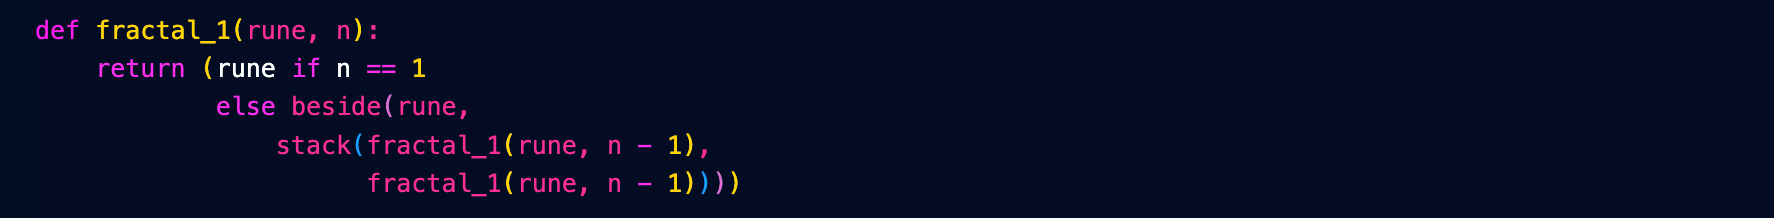 <br>

we can avoid this by defining a variable within the function for "intermediate values" so it only has to compute once <br>

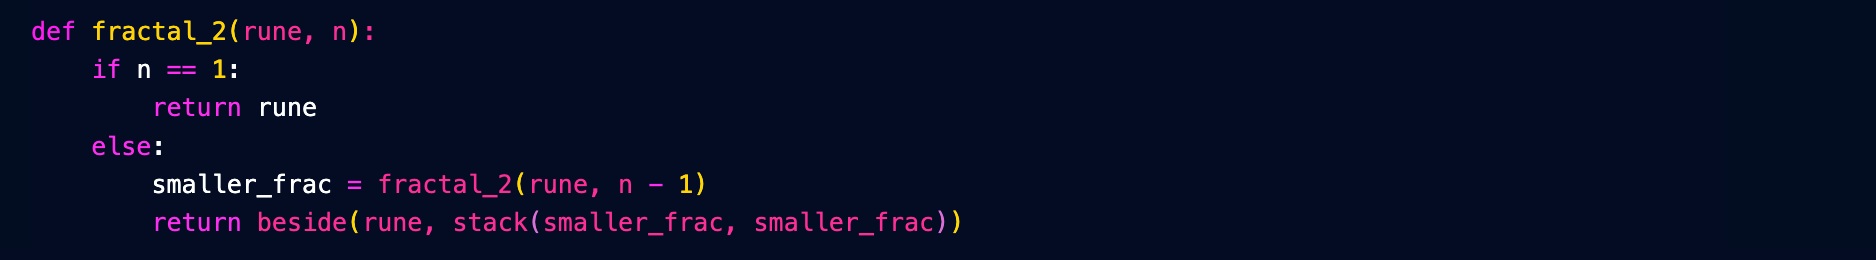


"conditional expression" --> what they call the onleine ternary operator stuff <br>
"conditional statements" --> the if/else blocks

OKAY PRACTICE TIME!!! <br><br>
try to create a coin counter function to return the number of ways u can come up with a certain value of cents using coins! <br>
⭐️ hint !! : create a helper function for the denominations

In [13]:
def cc(amt, cointype):
    def denom(cointype):
        return (
            5 if cointype == 1
            else 10 if cointype == 2
            else 20 if cointype == 3
            else 50 if cointype == 4
            else 100 if cointype == 5
            else 0
        )

    return (1 if amt == 0 
            else 0 if (amt < 0 or cointype == 0)
            else cc(amt-denom(cointype), cointype-1) + cc(amt, cointype-1) # pascal's identity!
            )

cc(120, 5)

1

In [14]:
# kinda cool sum of integers and cubes method (?)

def cube(x):
    return x*x*x

def sum_of_int(a, b):
    return 0 if a>b else a + sum_of_int(a+1, b)

def cube_of_int(a, b): # return sum of cubes of every other integer
    return 0 if a > b else cube(a) + cube_of_int(a+2, b)

cube_of_int(1, 3)

28

Lambda expressions! <br>
basically like a shorthand way of writing a function 

In [15]:
# e.g. 
def cube_1(x):
    return x*x*x

# is similar to

cube = lambda x : x*x*x
print(cube(2))

8


In [16]:
# emm idk what to call this?? functional abstraction??

def make_adder(x):
    def adder(y):
        return x+y
    return adder

make_adder(4)(5) #yup u can do this ig, i didnt know that tbh

9

scope of names <br>
sometimes same variable is declared at different places and it seems to work <br>
rule to apply: <u>closest surrounding declaration</u> -> when choosing which variable its referred to, it looks for the variable that was declared the closest <br>

In [17]:
# HOOOOLYYY SHIIIITTTT this path made me wanna kms

def sum(term, a, next, b):
    return (0 if a > b
            else term(a) + sum(term, next(a), next, b))

def sum_odd(n): # sum of the first n odd natural numbers
    a = 1
    b = n*2-1
    next = lambda x : x+2
    term = lambda y : y
    return sum(term, a, next, b)

def sum_odd_lte(n): # sum the first n odd numbers less than or equal to n.
    a = 1
    b = n
    next = lambda x : x+2
    term = lambda y : y
    return sum(term, a, next, n)

# GENERALISATION (TS KILLED ME BRUH)
def accumulate(combiner, term, a, next, b, base):
    return (base if a > b 
    else combiner(term(a), accumulate(combiner, term, next(a), next, b, base))
    )

# Example uses:

def sum(term, a, next, b):
    return accumulate(lambda x, y: x + y, term, a, next, b, 0)

def product(term, a, next, b):
    return accumulate(lambda x, y: x * y, term, a, next, b, 1)

def fact(n):
    return product(lambda x: x, 1, lambda x: x + 1, n)

# i need more practice on this bro

### Functional Expressionism!! [Quest]
#### Question 1<br>
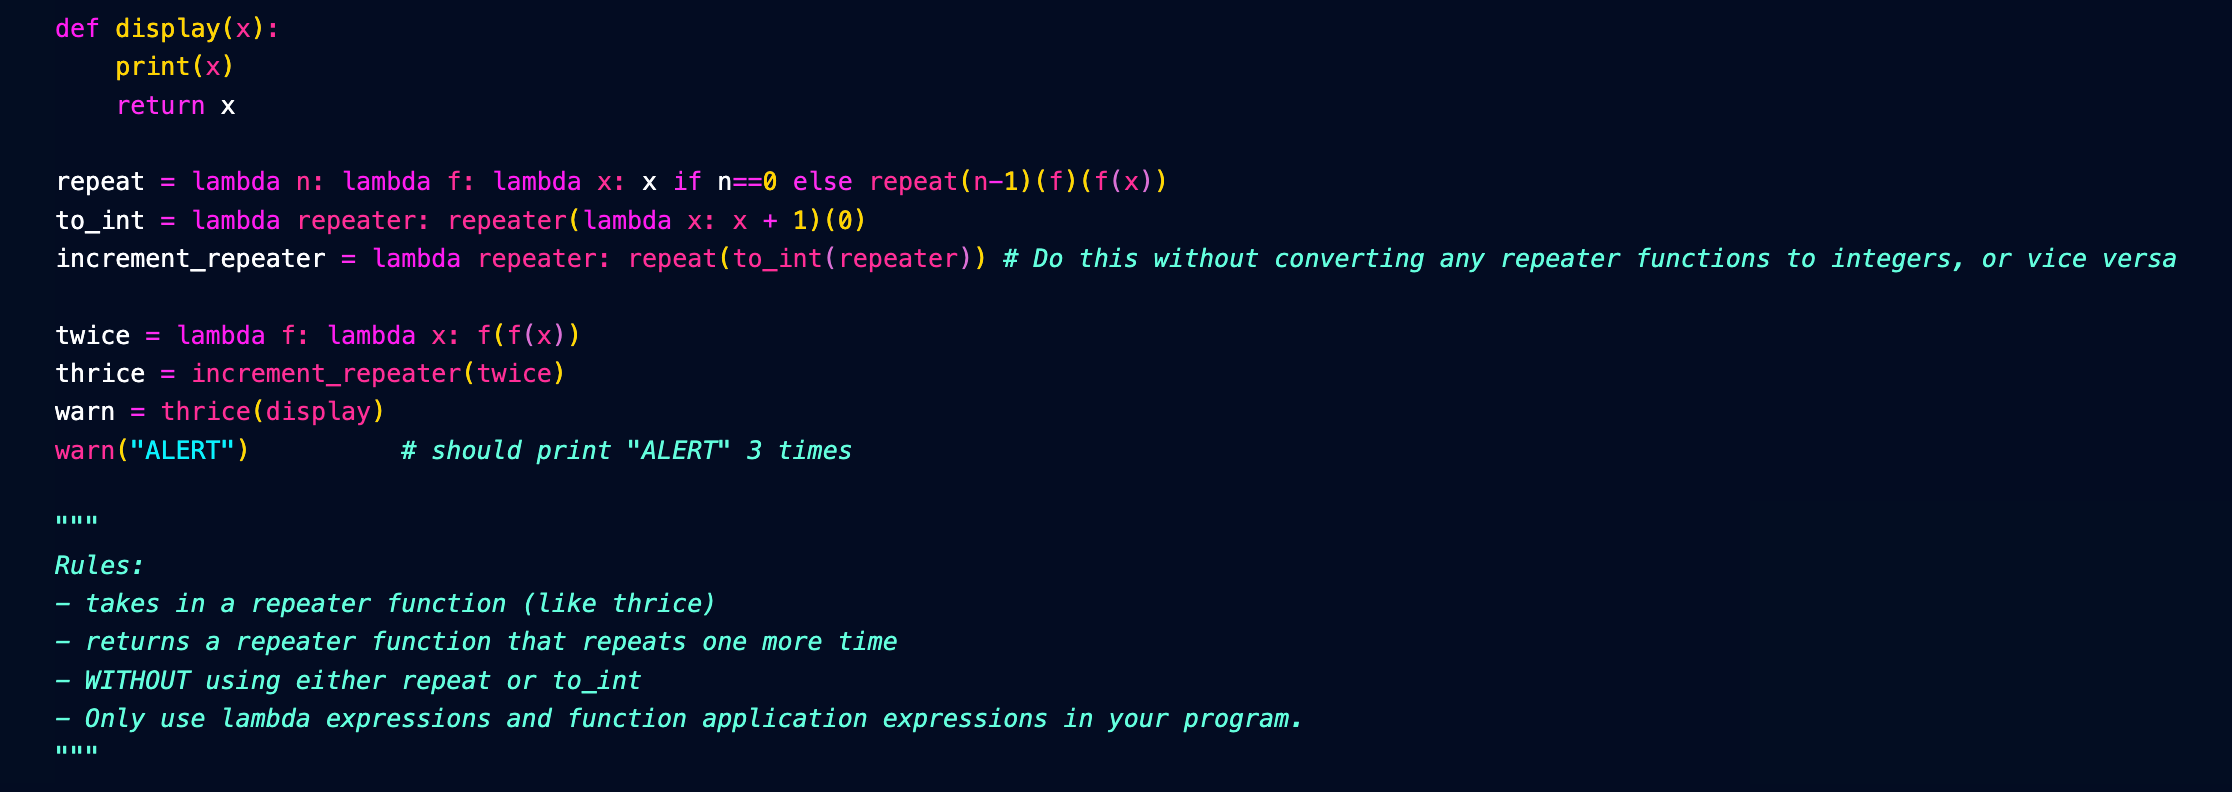

In [18]:
def display(x):
    print(x)
    return x

increment_repeater = lambda repeater: lambda f: lambda x: f(repeater(f)(x))
# i kept trying to do f(repeater(x)) but see that repeater takes in 2 parameters f and x so they must be given separately ykwim

twice = lambda f: lambda x: f(f(x))
thrice = increment_repeater(twice)
fourtimes = increment_repeater(thrice)
warn = fourtimes(display)
warn("ALERT")




ALERT
ALERT
ALERT
ALERT


'ALERT'

#### Question 2
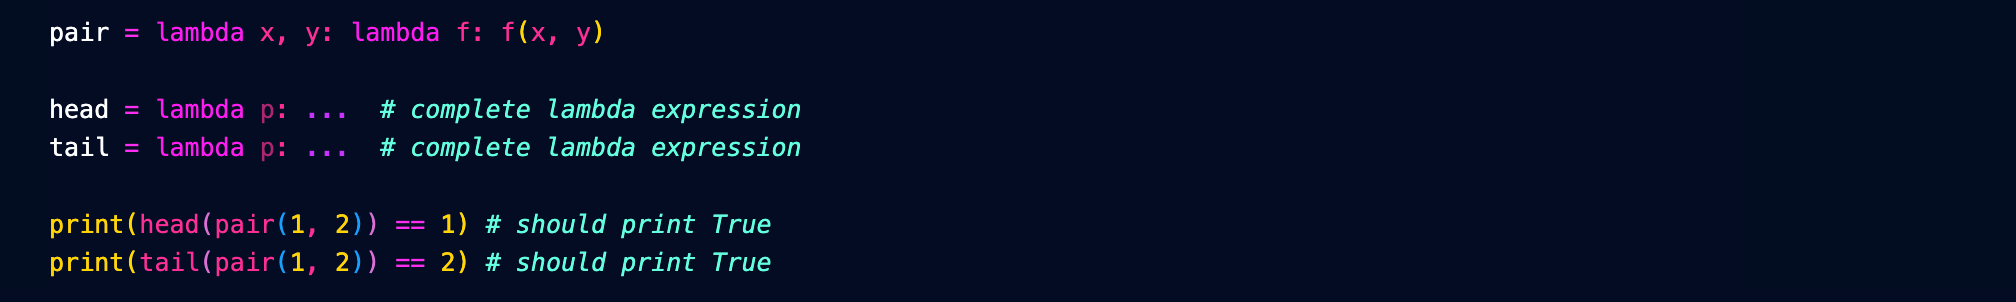

In [19]:
pair = lambda x, y: lambda f: f(x, y)

head = lambda p: p(lambda x, y: x)
tail = lambda p: p(lambda x, y: y)

print(head(pair(1, 2)) == 1)
print(tail(pair(1, 2)) == 2)

True
True


#### Question 3
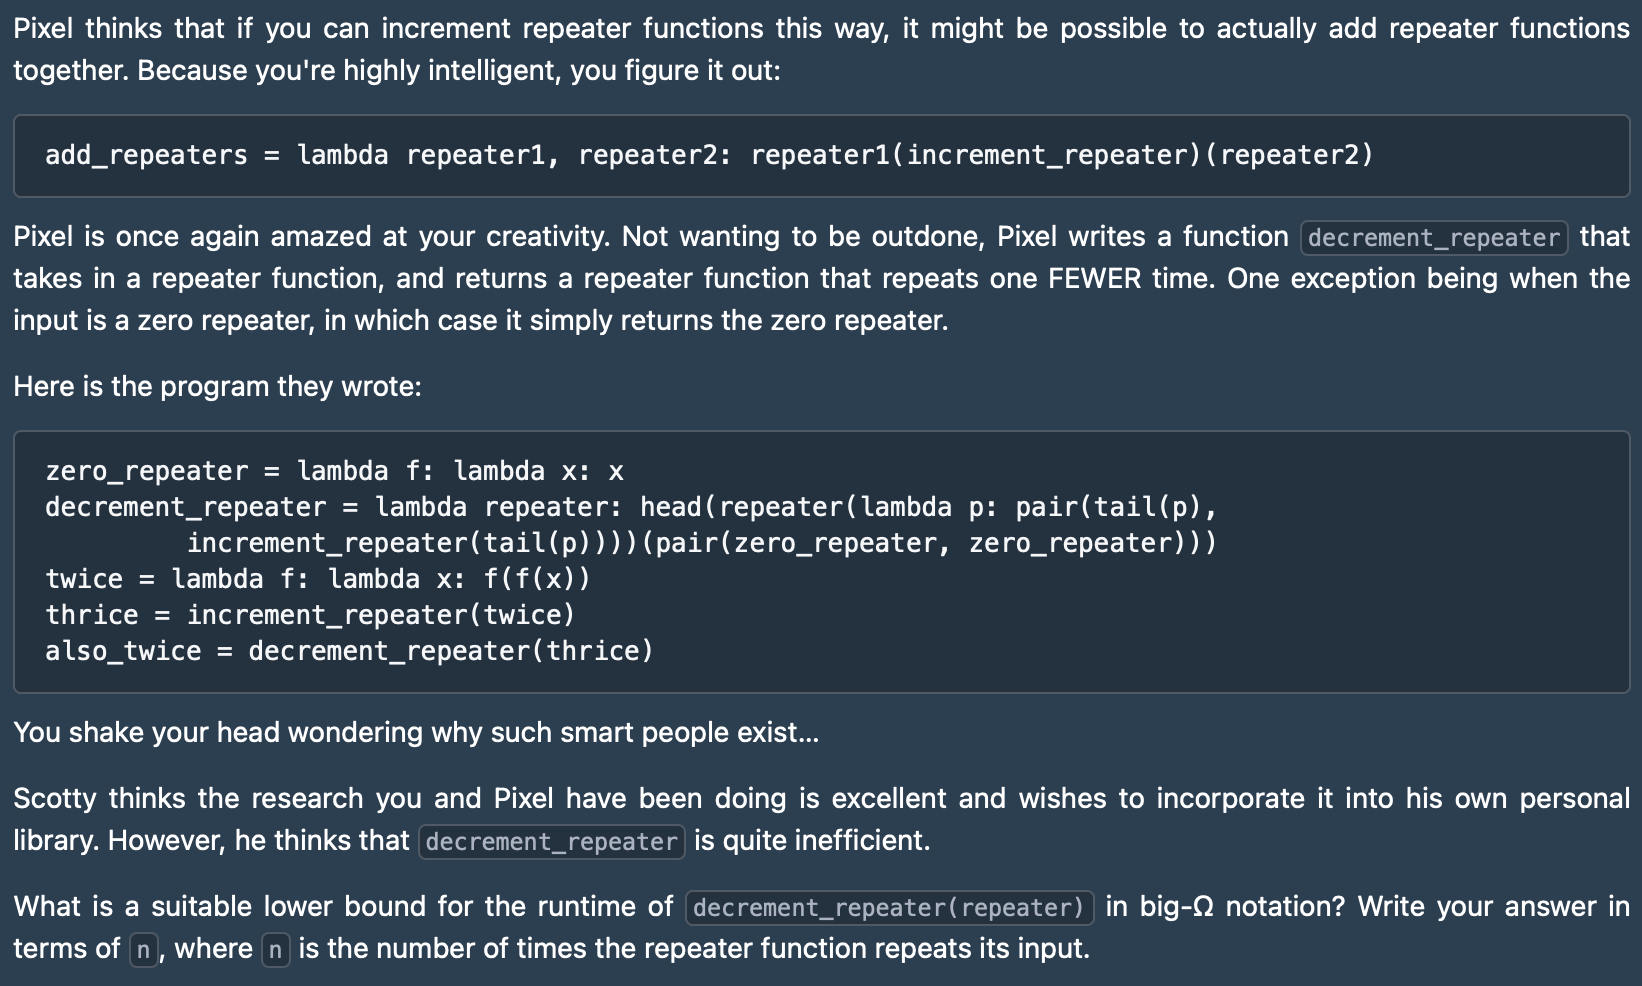

In [20]:
zero_repeater = lambda f: lambda x: x


decrement_repeater = lambda repeater: head(
    repeater(                               # this part gets executed n times since it's passing into repeater
        lambda p: pair(                     # how this works : p start is (zero_rep, zero_rep) -> (zero, once) -> (once, twice) -> (twice, thrice)
            tail(p),                        # basically this gets repeated n times (repeater=n) and the head is taken bec the head will be n-1
            increment_repeater(tail(p)))    # tail(p) only runs once per round. increment_repeater also runs once per round? so is big-Ω notation just n??
    )
    (pair(
        zero_repeater, # base case ig
        zero_repeater
    )
    )
)


twice = lambda f: lambda x: f(f(x))
thrice = increment_repeater(twice)
also_twice = decrement_repeater(thrice)

#### Question 4
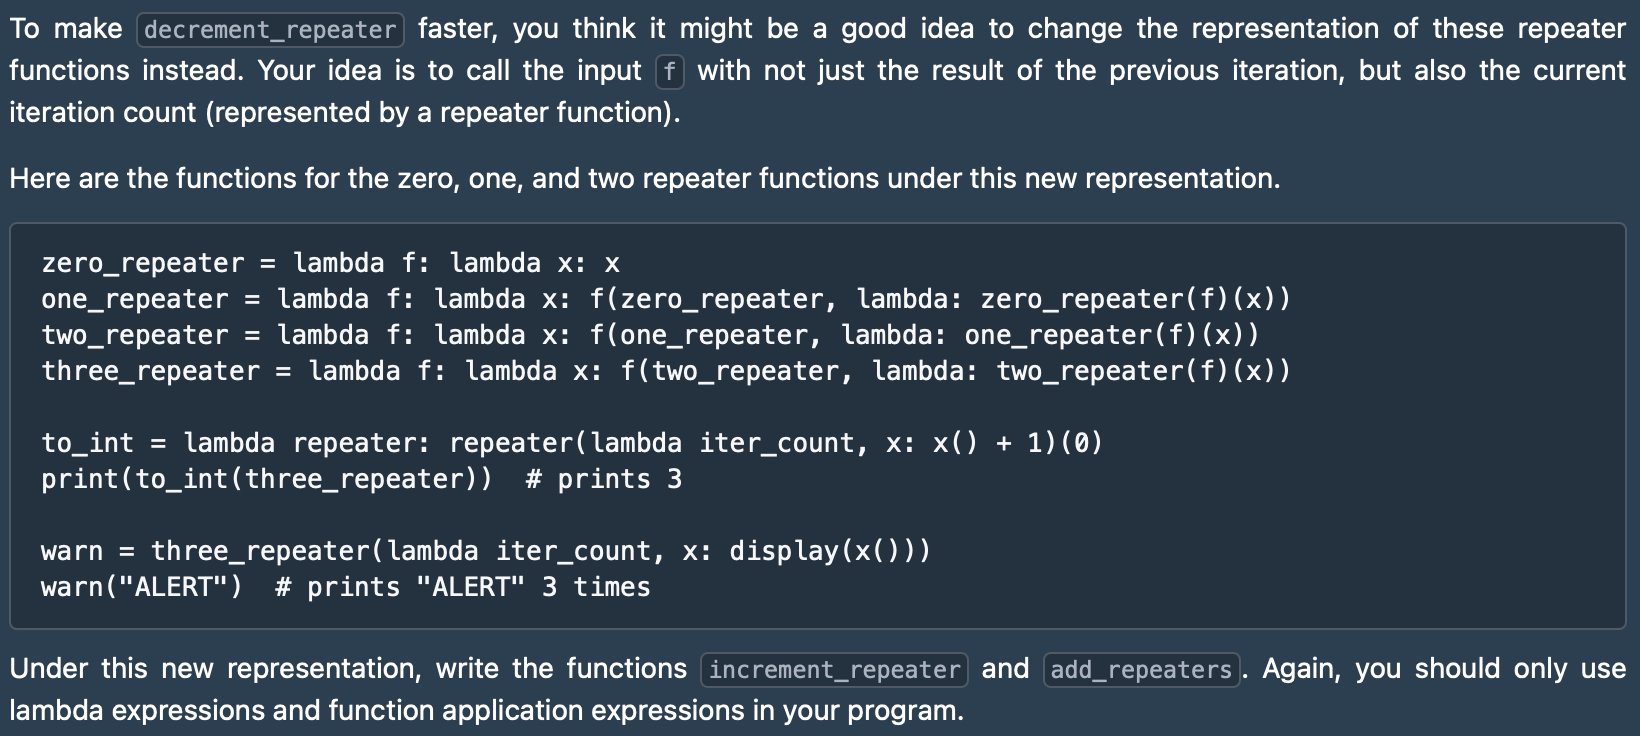

In [21]:
zero_repeater = lambda f: lambda x: x
increment_repeater = lambda repeater: lambda f: lambda x: f(repeater(f)(x))
one_repeater = increment_repeater(zero_repeater)
two_repeater = increment_repeater(one_repeater)
three_repeater = increment_repeater(two_repeater)

to_int = lambda repeater: repeater(lambda iter_count, x: x() +1)(0)

add_repeaters = lambda repeater1, repeater2: repeater1(increment_repeater)(repeater2)

print(to_int(add_repeaters(two_repeater, three_repeater)))  # should print 5

TypeError: <lambda>.<locals>.<lambda>() missing 1 required positional argument: 'x'

#### Question 5
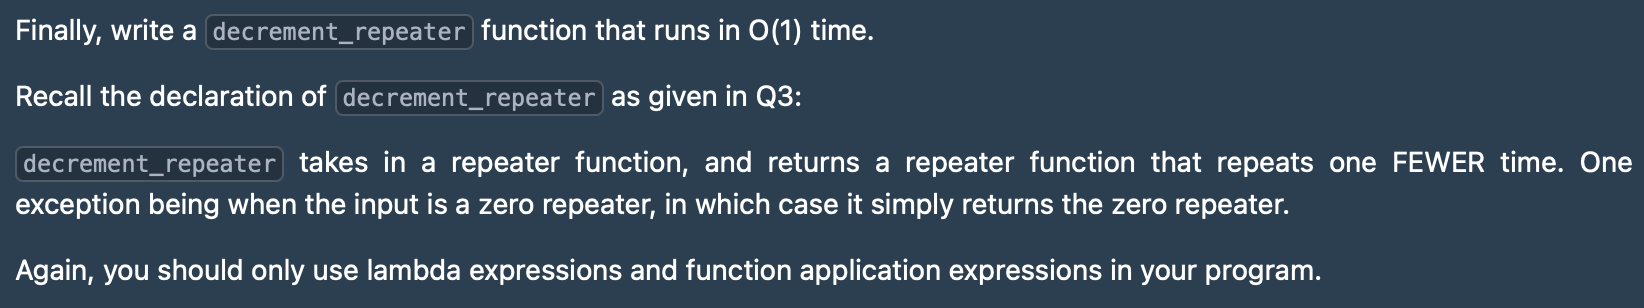

In [ ]:
zero_repeater = lambda f: lambda x: x
one_repeater = lambda f: lambda x: f(zero_repeater, lambda: zero_repeater(f)(x))
two_repeater = lambda f: lambda x: f(one_repeater, lambda: one_repeater(f)(x))
three_repeater = lambda f: lambda x: f(two_repeater, lambda: two_repeater(f)(x))

to_int = lambda repeater: repeater(lambda iter_count, x: x() +1)(0)
decrement_repeater = lambda repeater: repeater(lambda iter_count, x: iter_count)(zero_repeater)


print(to_int(decrement_repeater(three_repeater)))  # should print 2

2


# LECTURE 6 [28/08/26]
logical operators (and/or)
basically unlike a real binary operator, the <u>right hand expression is not always evaluated</u>! <br>
this is bec for P or Q, if P is true then P∨Q is true for any Q <br>
similarly if P is false, P∧Q is false for any Q <br>

In [ ]:
# e.g.
def boom():
    return 1/0 # wld crash if it ran

print(False and boom())
print(True or boom()) # runs without crashing bec the RHS expression is ignored

# this is called "laziness"

False
True


In [ ]:
# dont test these it wont run lmao

import math

p = make_point(1, 1)

def print_point(p):
    print("point: ", x_of(p), y_of(p))

def line_with(m, h):
    return lambda t: make_point(t, m*t+h)
    

def unit_circle(t):
    return make_point(
        math.cos(2 * math.pi * t),
        math.sin(2 * math.pi * t)
        )

def spiral_one(t):
    p = unit_circle(t)
    return make_point(t * x_of(p), t * y_of(p))

def spiral(rev):
    def spiral_helper(t):
        p = unit_circle((t*rev) % 1)
        return make_point(t* x_of(p), t* y_of(p))
    return spiral_helper

#draw_connected_full_view_proportional(2000)(spiral(20))
#draw_connected_full_view_proportional(100)(unit_circle)
#draw_connected_full_view_proportional(20)(line_with(2, 3)) #the number refers to the number of points this runs thru


# STUDIO 3 [31/08/26]

### Question 1
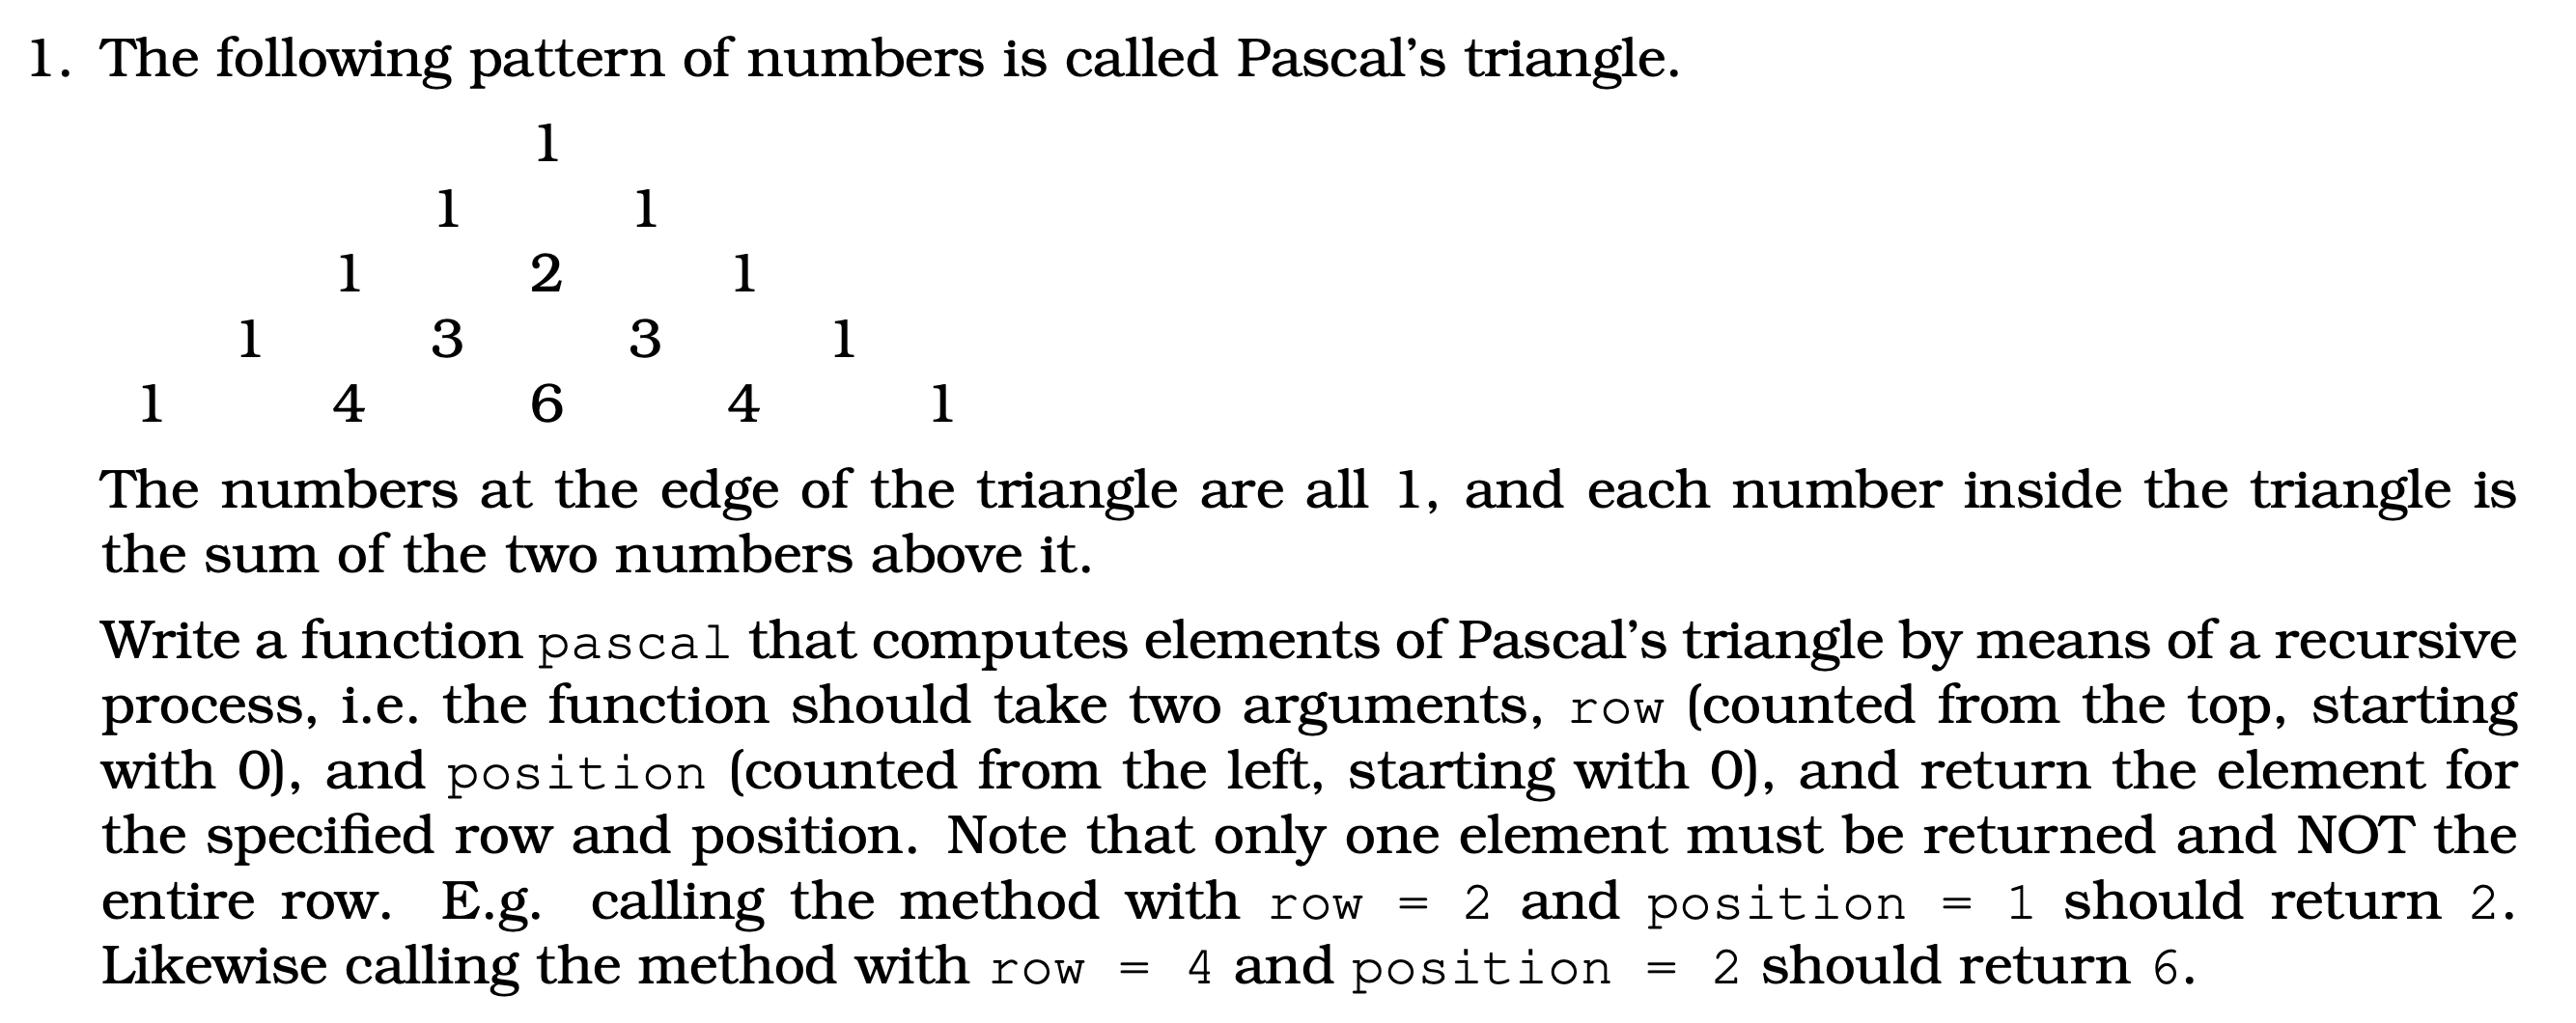

In [ ]:
def pascal(n, r):
    return (0 if r>n 
            else 1 if r == n or r == 0
            else pascal(n-1, r) + pascal(n-1, r-1))

pascal(5, 1)

5

BTW math.log() defaults to natural log (base e) not base 10

### inclass studio sheet
#### question 1
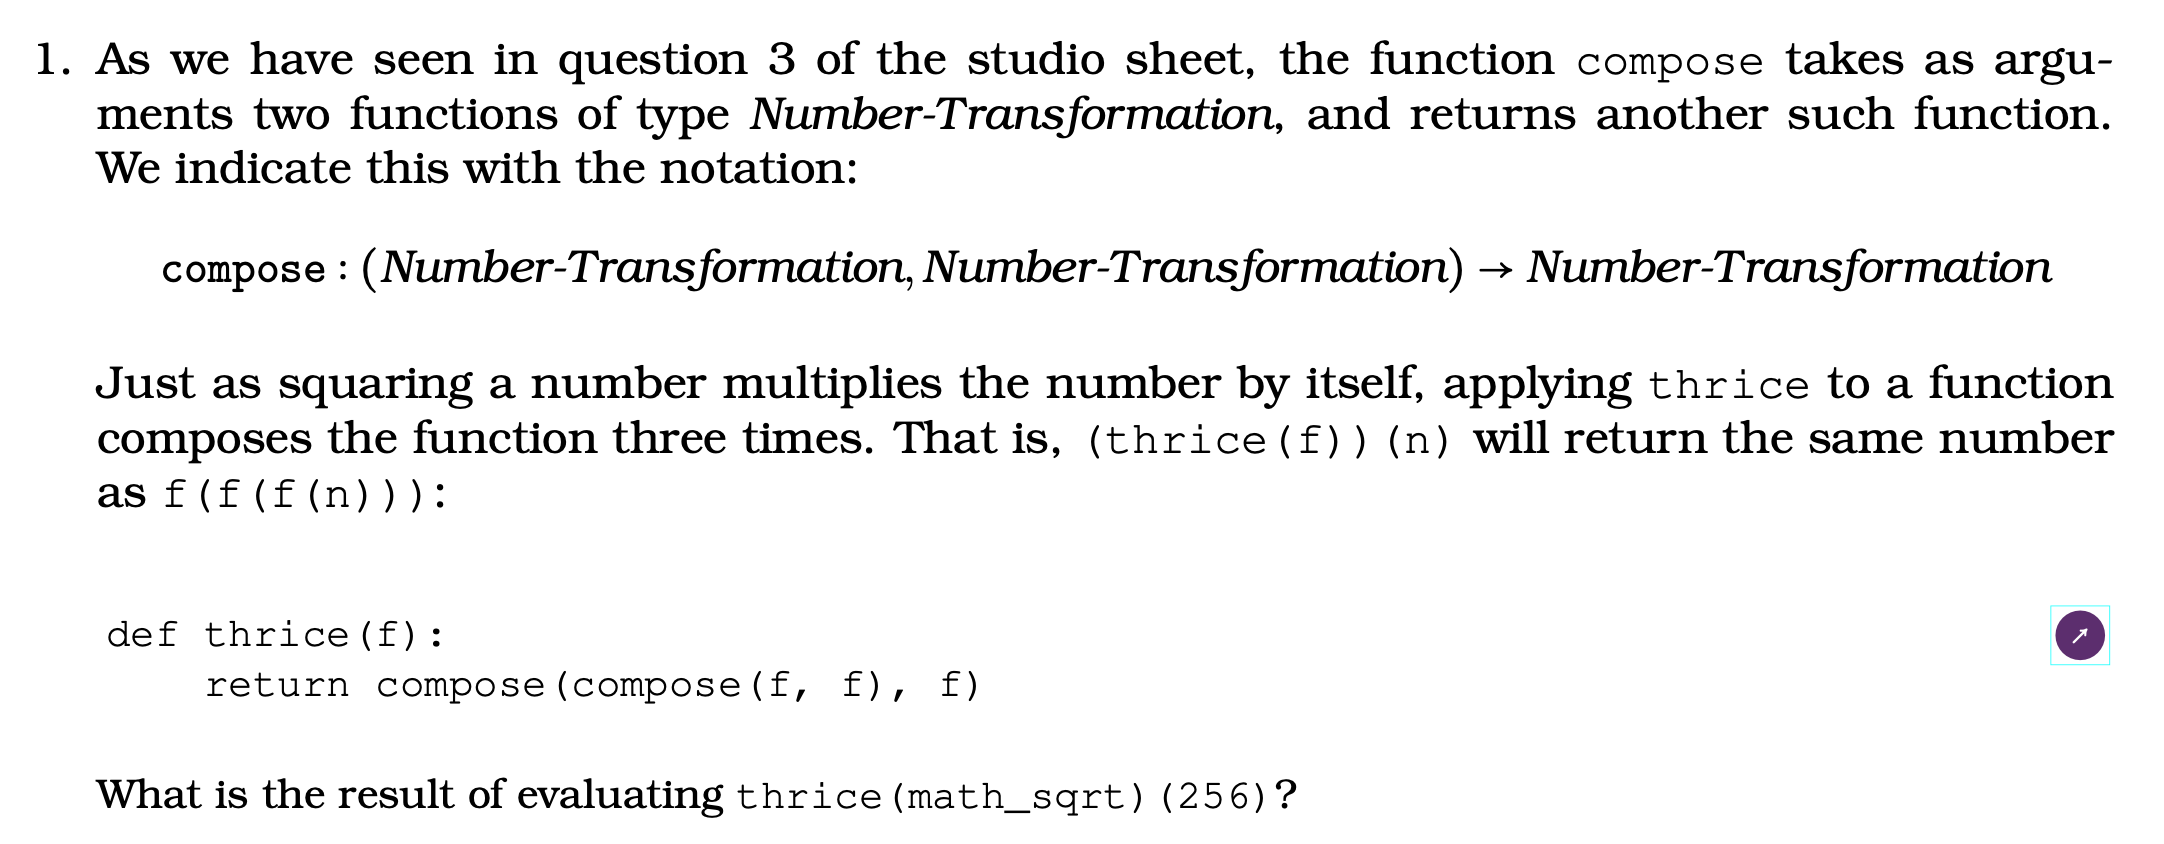

In [ ]:
import math
def compose(f, g):
    return lambda x: f(g(x))

def thrice(f):
    return compose(compose(f, f), f)

# aka thrice(f): lambda x: f(f(f(x)))

print(math.sqrt(math.sqrt(math.sqrt(256))))

2.0


#### question 2
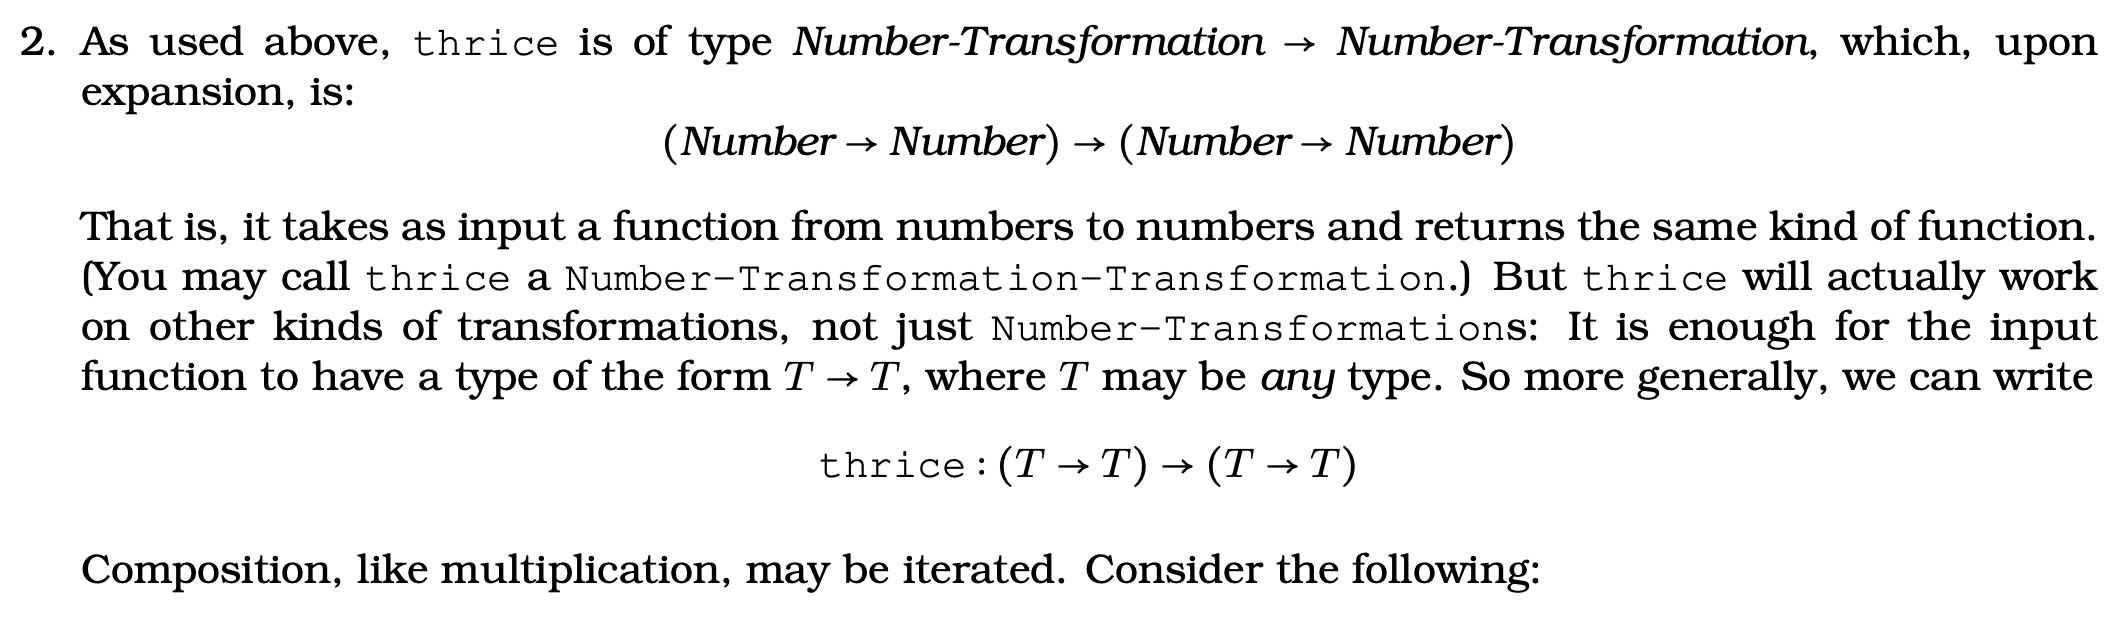
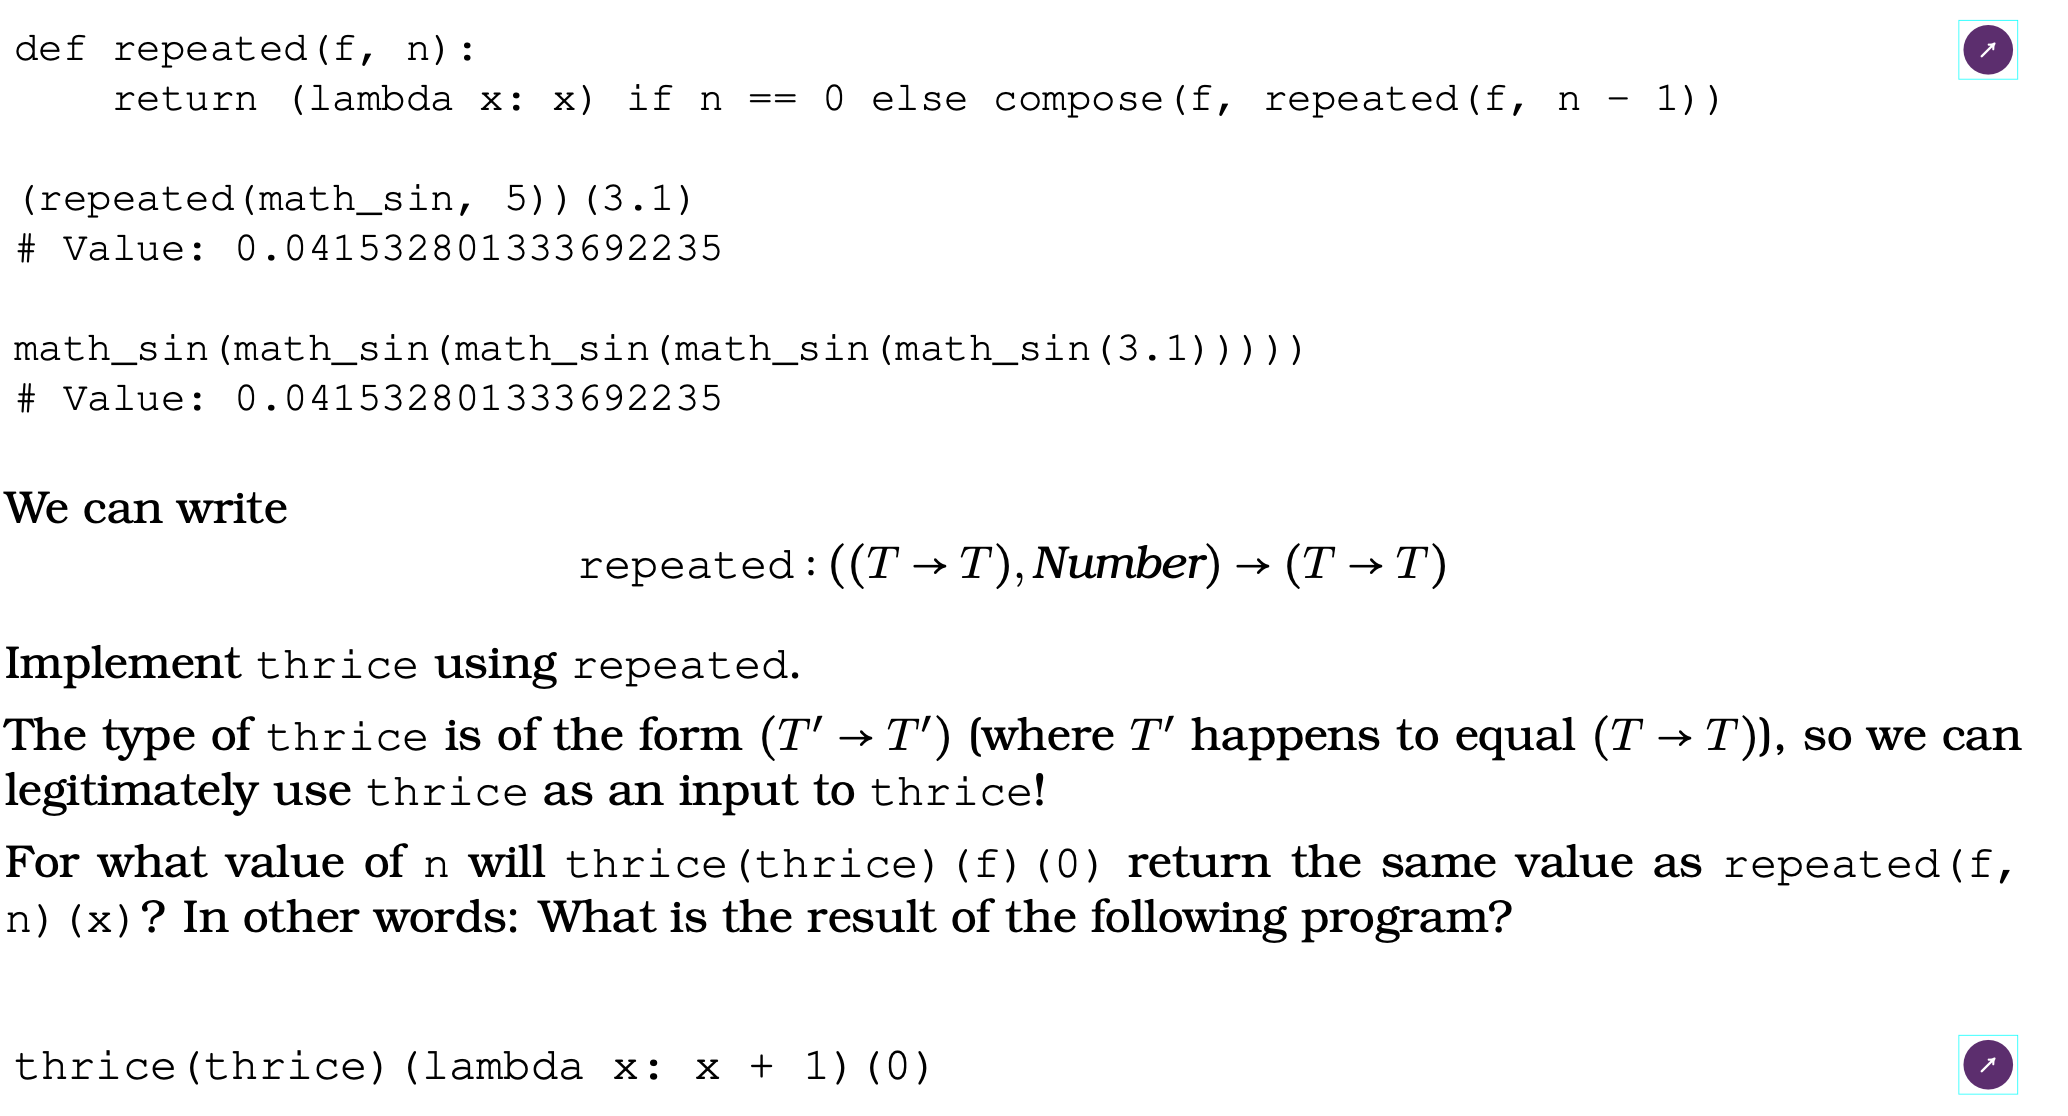

In [ ]:
def repeated(f, n):
    return (lambda x: x) if n == 0 else compose(f, repeated(f, n-1))

# implement thrice using repeated

def thrice(f):
    return repeated(f, 3)

# for what value of n will thrice(thrice)(f)(0) return the same value as repeated(f, n)(x)?
'''
thrice(thrice)(f)(0) = repeated(thrice, 3)(f)(0) 
= thrice(thrice(thrice))(f)(0)
= f^(27)(0)
'''
# what is the result of the following program?

thrice(thrice)(lambda x: x+1)(0) = 27

27


#### question 3
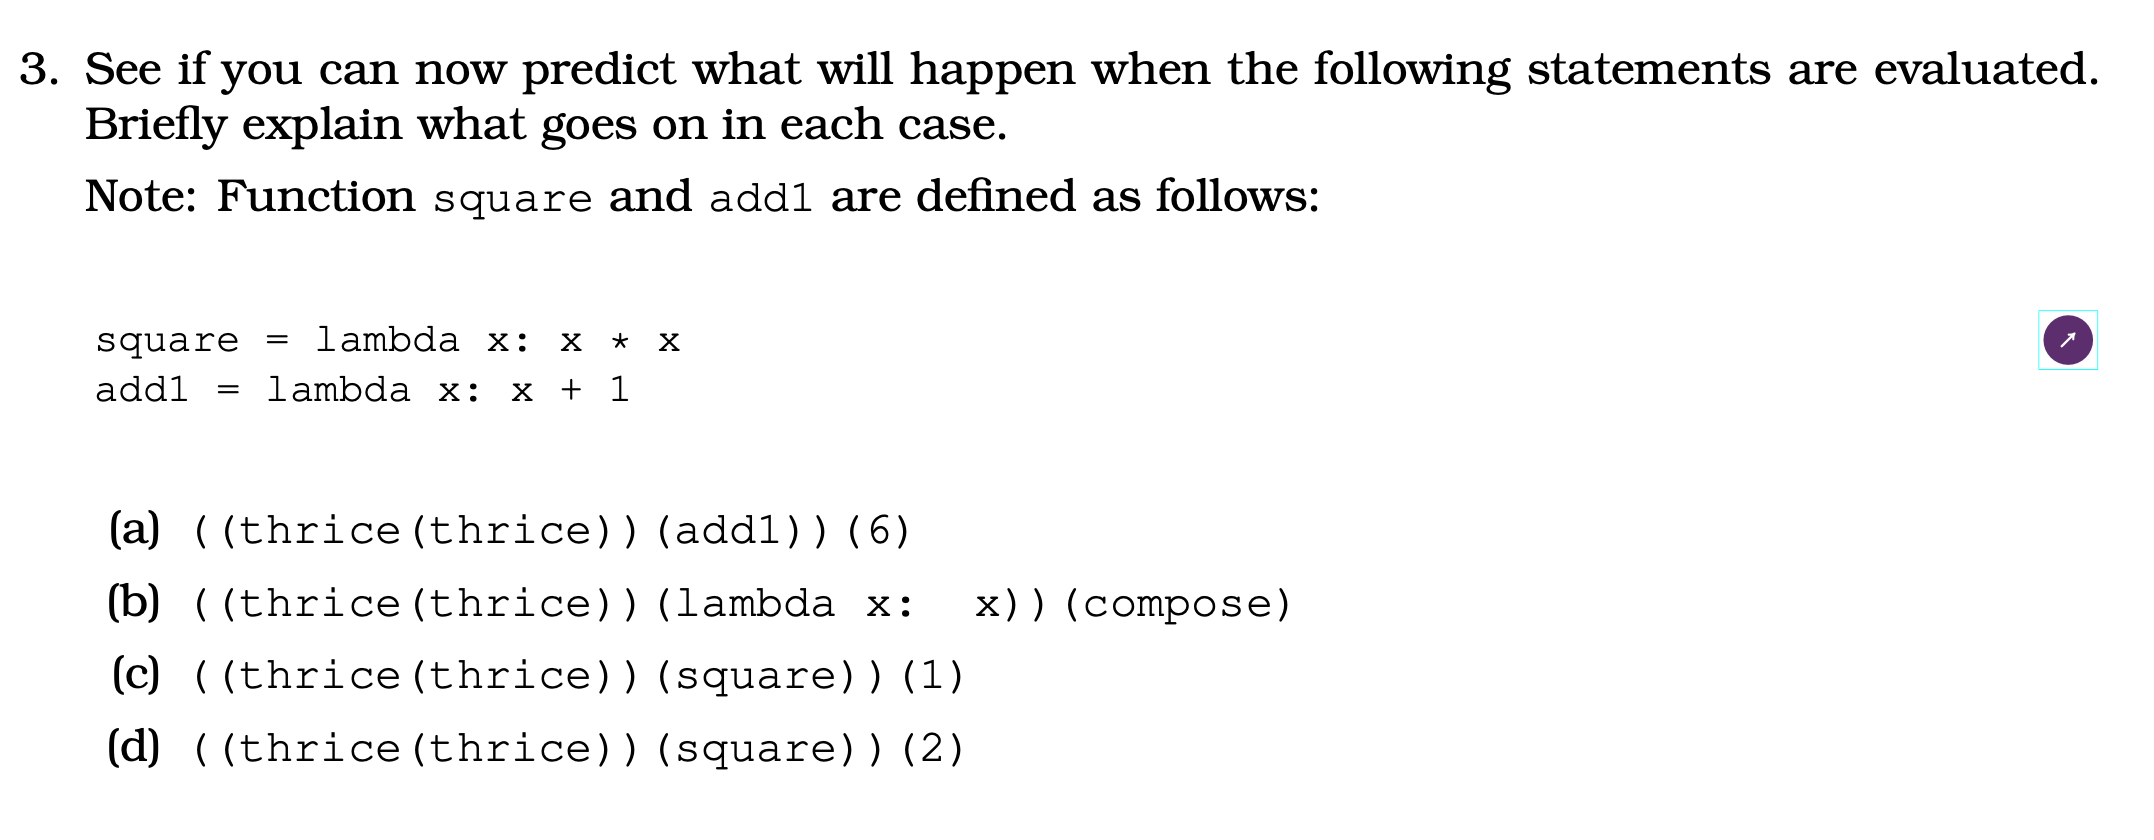

In [ ]:
square = lambda x: x*x
add1 = lambda x: x+1

# (a)
((thrice(thrice))(add1))(6) # = 6+27 = 33 riiiiightttt??

# (b)
((thrice(thrice))(lambda x: x))(compose) # compose

# (c)
((thrice(thrice))(square))(1) # 1

# (d)
((thrice(thrice))(square))(2) # (2^2)^2 ... 27 times An Extremely Large Number

# LECTURE 7 [02/09/26]
introduction to data abstraction~

yippee data structures! e.g. pairs, tuples, sets, matrices <br>
tuples are kinda like arrays? whats the difference i dont rmb


In [ ]:
pair = lambda x, y: lambda f: f(x, y)

head = lambda p: p(lambda x, y: x)
tail = lambda p: p(lambda x, y: y)
head(pair(6, 7))

6

In [ ]:
# rational numbers implementation !!
# rational numbers can be expressed as a pair of numerator and denominator

def make_rat(n, d):
    return pair(n, d)

def numer(x):
    return head(x)
def denom(x):
    return tail(x)

# operations of rational numbers

def add_rat(x, y):
    return make_rat(numer(x)*denom(y) + numer(y)*denom(x) , denom(x)*denom(y))

def mult_rat(x, y):
    return make_rat(numer(x)*numer(y) , denom(x)*denom(y))

def div_rat(x, y):
    return make_rat(numer(x)*denom(y) , denom(x)*numer(y))

# equality of rational numbers

def eq_rat(x, y):
    return numer(x)*denom(y) == numer(y)*denom(x)

# why not return numer(x)==numer(y) and denom(x)==denom(y) ??

def rat_to_string(x):
    return (str(numer(x)) + "/" + str(denom(x)))

In [ ]:
one_third = make_rat(1, 3)
one_half = make_rat(1, 2)

rat_to_string(add_rat(one_third, one_half))

'5/6'

In [ ]:
def gcd(a, b):
    return a if b == 0 else gcd(b, a%b) # euclid's alg

# lets trace euclid's alg!
# e.g. gcd(24, 9)          -> 9 != 0       -> gcd(9, 24%9)
# gcd(9, 6)                -> 6 != 0       -> gcd(6, 9%6)
# gcd(6, 3)                -> 3 != 0       -> gcd(3, 0)
# gcd(3, 0)                -> 0 == 0       -> return 3
# why does this work? ifl this wld be pretty cool enlightening further reading. for later.

def make_rat(n , d):
    g = gcd(n , d)
    return pair( n // g , d // g )

rat_to_string(make_rat(2, 4)) #prints 1/2

'1/2'

and that's what data abstraction is about <br><br>
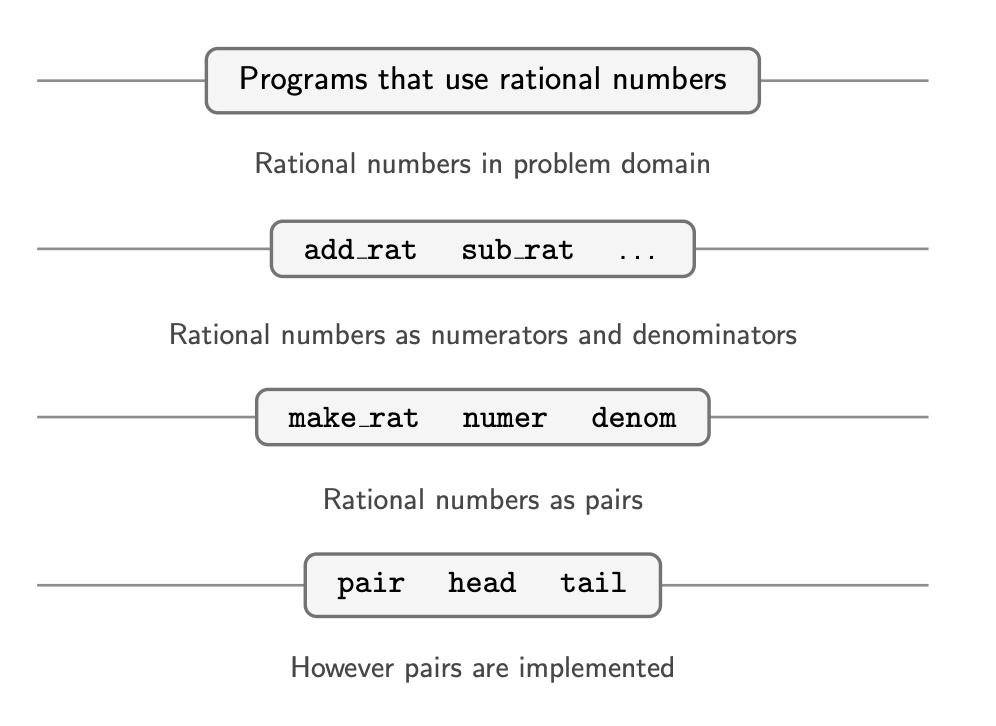 <br><br>
u shld never break the abstraction barrier --> means u shld never directly change code in the "lower level implementation" but rather always the "higher levels of abstraction"

In [ ]:
#e.g. with the coin counter
first_denomination = pair(100, pair(50, pair(20, pair(10, 5)))) # many different ways of nesting pairs
head(first_denomination) # --> gives 100

# head must always be data -> standardised to avoid diff patterns
# what about the last pair pair(10, 5) -> pair(5, ...)
# the ... is a NoneType which shld be declared so that nothing gets violated

denoms = pair(100, pair(50, pair(20, pair(10, pair(5, None))))) # this is a linked list!

linked list: either None or a pair whose tail is a linked list (AKA a llist) <br>
empty linked lists are printed as None <br>
this is a recursive definition btw!

In [ ]:
head(denoms) #100
head(tail(denoms)) #50
head(tail(tail(denoms))) #20 #ehhh why does this only return 20 and not 100 and 50 too ? does this mean that it will only return the last statement ?????

20

In [ ]:
print(denoms) # u cant just print like this on actl python i think

<function <lambda>.<locals>.<lambda> at 0x109ce5760>


length of a linked list
- length of None is 0
- length of llist = one more than the length of the tail

In [ ]:

def length(xs):
    return 0 if is_none(xs) else 1 + length(tail(xs)) #this is recursive

### REC 3! [03/09/26]

why can None represent a linkedlist $\rightarrow$ because it represents an empty list


In [ ]:
def is_pair(obj):
    return isinstance(obj, tuple) and len(obj) == 2

def is_llist(xs):
    return (True 
            if xs == None 
            else is_llist(tail(xs)) if is_pair(xs)
            else False)

#is_llist(3) #False
#is_llist(pair(1, pair(2,3))) #False
is_llist(pair(1, pair(2, pair(3, None)))) #True

False

In [ ]:
def print_llist(p):
    if p is None:
        return None
    return p(lambda x, y: [x, print_llist(y)])

xs = pair(1, pair(2, pair(3, None)))

print(xs) #prints a function
print_llist(xs) #prints list notation

<function <lambda>.<locals>.<lambda> at 0x109ce59e0>


[1, [2, [3, None]]]

In [ ]:
# wait this was quite hard u shld try this later:
# Draw the box-and-pointer diagrams for the results of evaluating this:
pair(pair(pair(3, 2), pair(1, 0)), None)

<function __main__.<lambda>.<locals>.<lambda>(f)>

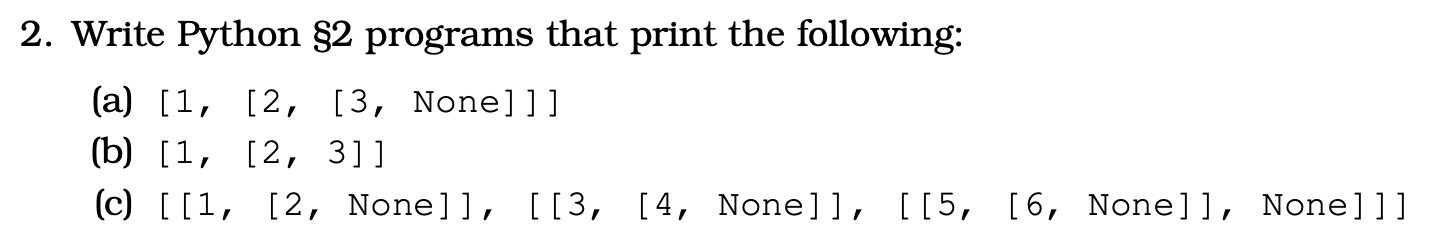

In [ ]:
# (a)
print_llist(pair(1, pair(2, pair(3, None))))
# (b)
print_llist(pair(1, pair(2, 3))) #shld return error ??
# (c)
print_llist(pair(pair(1, pair(2, None)), pair(pair(3, pair(4, None)), pair(pair(5, pair(6, None)), None))))

# STUDIO 5 [07/09/26]
### Box & Pointer Diagrams

In [ ]:
llst1 = llist(7, llist(6, 5, 4), 3, llist(2, 1)) #[7, [[6, [5, [4, None]]], [3, [[2, [1, None]], None]]]]
print(head(tail(head(tail(tail(tail(llst1)))))))

llst2 = llist(llist(7), llist(6, 5, 4), llist(3, 2), 1) #[[7, None], [[6, [5, [4, None]]], [[3, [2, None]], [1, None]]]]
print(head(tail(tail(tail(llst2)))))

llst3 = llist(7, llist(6), llist(5, llist(4)), llist(3, llist(2, llist(1))) ) # [7, [[6, None], [[5, [[4, None], None]], [[3, [[2, [[1, None], None]], None]], None]]]]
print(head(head(tail(head(tail(head(tail(tail(tail(llst3))))))))))

llst4 = llist(7, llist(llist(6, 5), llist(4), 3, 2), llist(llist(1))) # [7, [[[6, [5, None]], [[4, None], [3, [2, None]]]], [[[1, None], None], None]]]
print(head(head(head(tail(tail(llst4))))))

# might be easier to draw box and pointer / use draw_data()

1
1
1
1


the point of data abstraction is to "hide the lower level implementation" thats why u shld always use the higher level functions like numer() and denom() instead of head() and tail(). <br>
client vs implmentor: we expose methods to clients to use but they dont need to know how it was implemented <br>

recap of linkedlists
- create via pair(x, pair(y, ...)) or directly like llist(<values>)
- u can use draw_data(llst) to visualise

In [ ]:
[2, [[5, [6, None]], 11]]
[1, [2, [[4, 5], [7, None]]]]

[[[7, 8], [1, [2, None]]], 6]
[llist([7,8], 1, 2), 6]

##### in-class sheet!
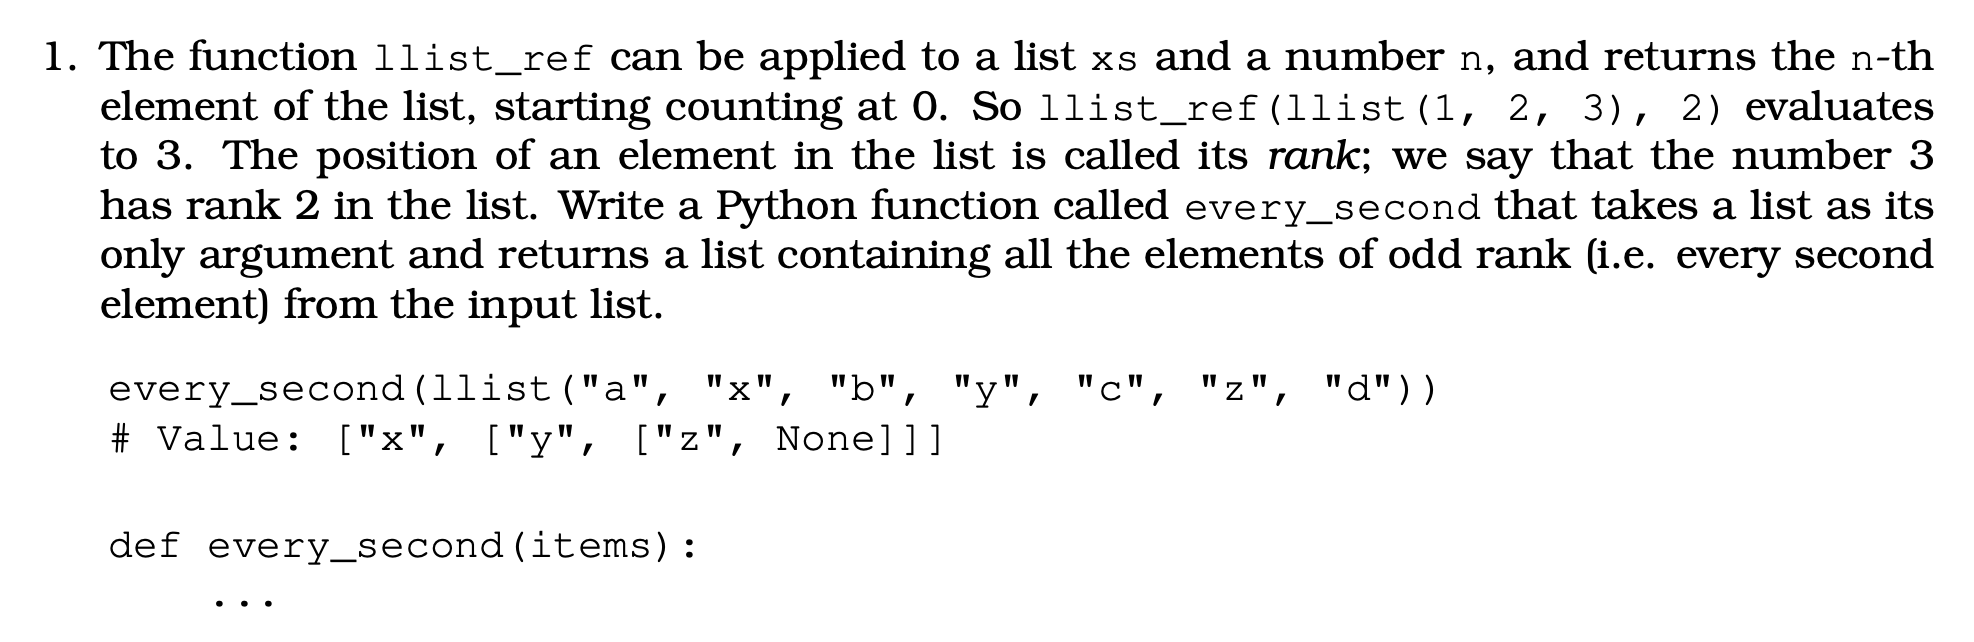

# LECTURE 8 [09/09/26] --- linked list processing

In [ ]:
#e.g.
def repeat(t, n):
    return lambda x: x if n == 0 else repeat(t, n-1)(t(x))

# repeat(t, n-1)(t(x)) -> is computed tgt

note: a llist shld be of a certain datatype only so its either None or a pair whose tail is a llist of the same datatype <br>
e.g. a llist of numbers, booleans, strings, etc <br>

In [ ]:
llistD = None #can be a llist of any type

In [ ]:
def append(xs, ys):
    return (ys 
            if is_none(xs)
            else pair(head(xs), append(tail(xs), ys)))

- what is the order of growth in time -> count number of function calls <br>
- order of growth in space -> count number of deferred operations -> creation of the pair is counted <br>
- but thats not the only type of space requirement! pairs requires space too! <br>
- n = length of xs = number of deferred operations & of pairs hence <b>θ(n)</b> <br>

refining space complexity
- counting number of pairs -> number of times the word "pair" is used
- accessing the pair does not require memory its only when it is <i>created</i>
- <u>if the pair is never being used, then its not a new pair being created every time but rather its replaced!!</u>

In [ ]:
# e.g.
def f(x):
    local_pair = pair("some head", "some tail")
    return 0 if x == 0 else f (x - 1)
f(100) 
# looks like 101 pairs get created
# but previous pair gets discarded every time the function is called

# e.g. what if the pair is called
def f(x, p):
    return None if x==0 else f(x-1, pair(p,p))
f(10, None)

# f(9, [None, None]) -> f(8, [[None, None], [None, None]]) -> ...

- since for each function call a new pair is being created and remembered, theres 10 pairs in memory -> ∴ O(n) memory
- substitution model may make it look like >10 pairs are created but that doesn't increase the memory

In [ ]:
# reversing a linkedlist! like the tutorial qn

def reverse2(llst): #recursive
    return (None
            if is_none(llst)
            else append(reverse2(tail(llst)), llist(head(llst))))
# the llist() is required around head because append() takes in 2 llists

# runtime : both append() and reverse1() are θ(n) so it shld be θ(n^2)
# space : number of pairs created is O(n^2) but only O(n) is needed to be remembered

def reverse3(xs): #iterative
    def rev(original, reversed):
        return (reversed
                if is_none(original)
                else rev(tail(original), pair(head(original), reversed)))
    return rev(xs, None)

In [ ]:
# scaling a linkedlist

def scale_list(xs, k):
    return (None
            if is_none(xs)
            else pair(k*head(xs), scale_list(tail(xs), k)))

In [16]:
# mapping

def map(f, xs):
    return (None
            if is_none(xs)
            else pair(f(head(xs)), map(f, tail(xs))))

In [17]:
# linkedlist filter abstraction

def filter(pred, xs):
    return (None
            if is_none(xs)
            else pair(head(xs), filter(pred, tail(xs)))
                if pred(head(xs))
                else filter(pred, tail(xs)))

In [ ]:
# summing elements in a llist

def llist_sum(xs):
    return (0
            if is_none(xs)
            else head(xs) + llist_sum(tail(xs))) # very similar to length() but u add head(xs) instead of 1
# right-to-left folding

# abstracting this
def reduce(op, initial, xs): # op is the deferred operation
    return (initial
            if is_none(xs)
            else op(head(xs), reduce(op, initial, tail(xs))))

#### path!!

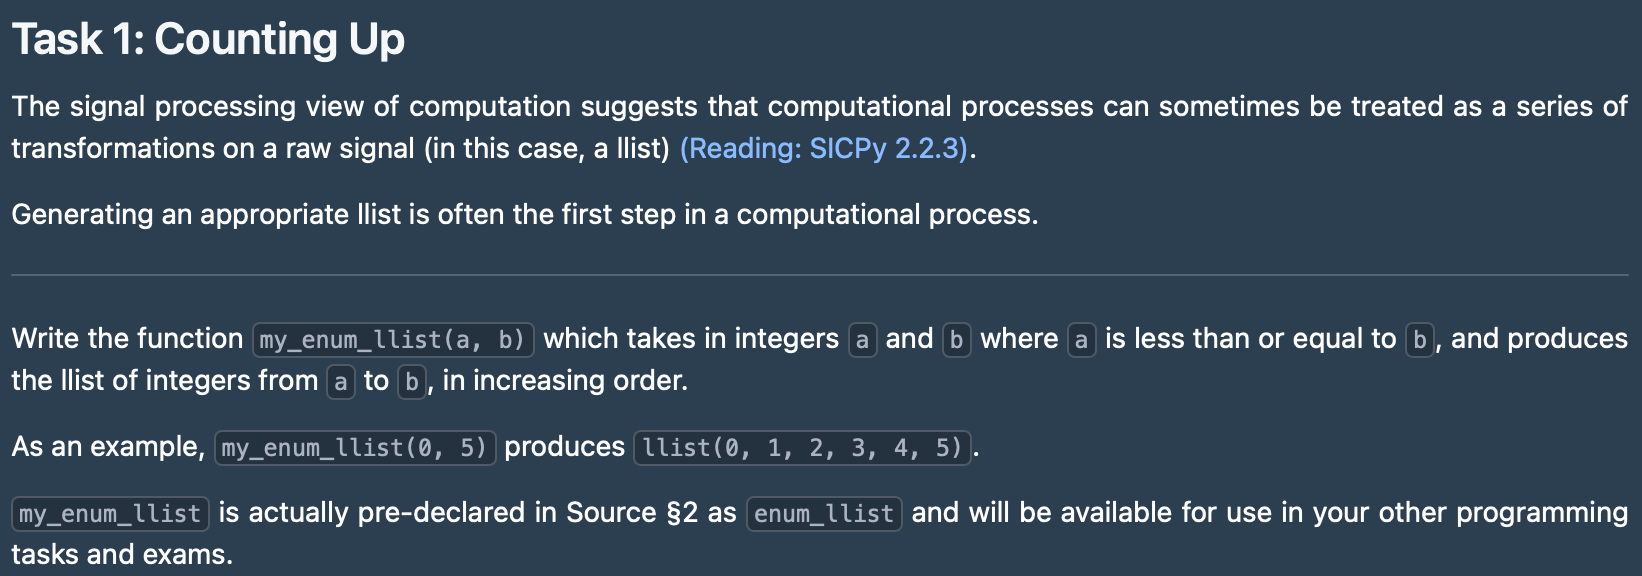

In [19]:
def my_enum_llist(a, b):
    return (None 
    if a>b
    else pair(a, None) if a == b
    else pair(a, my_enum_llist(a+1, b))
    )

# my_enum(0, 3) -> llist(0, 1, 2, 3) -> [0, [1, [2, [3, None]]]]
# -> [a, enum(1, 3)] -> [0, [1, enum(2, 3)]] -> [0, [1, [2, enum(3, 3)]]] -> [0, [1, [2, [3, None]]]]

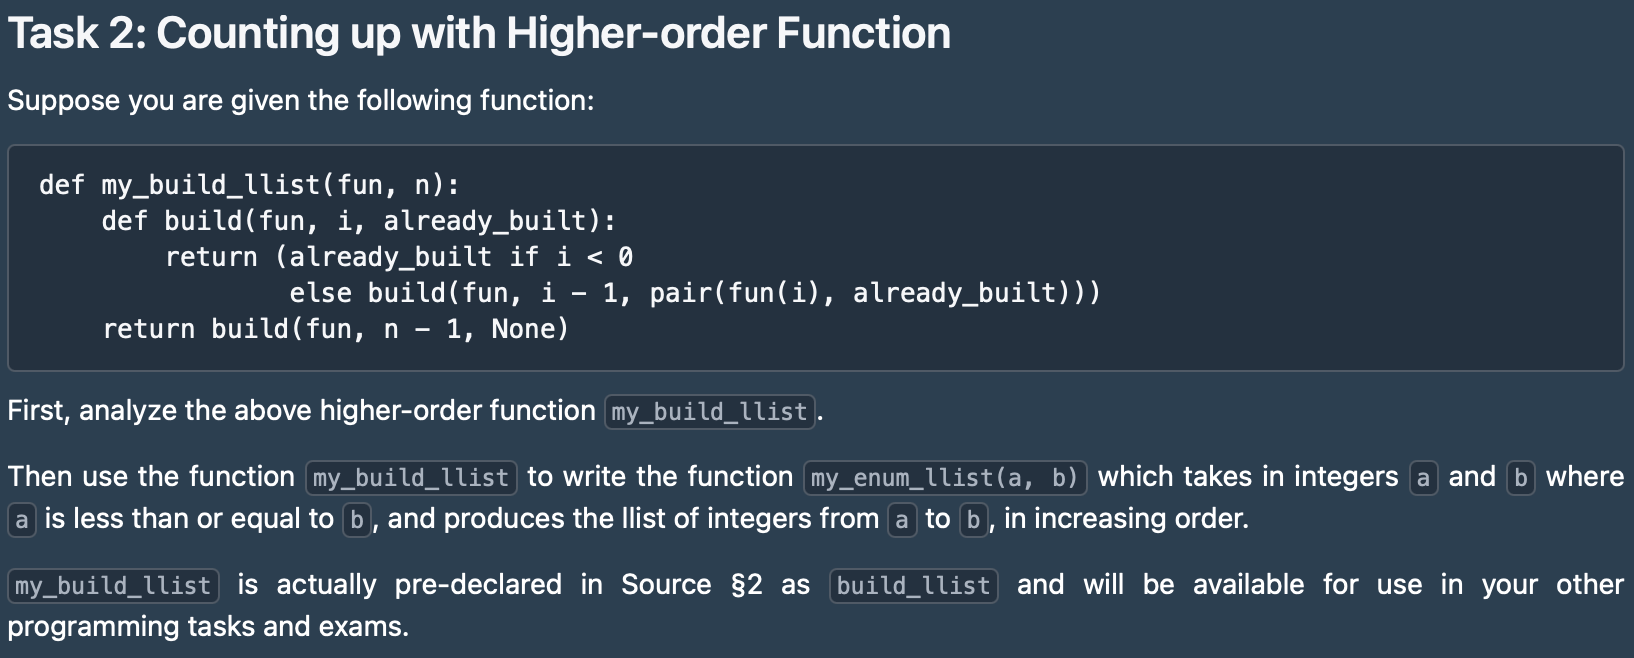

In [20]:
def my_build_llist(fun, n):
    def build(fun, i, already_built):
        return (already_built if i < 0
                else build(fun, i - 1, pair(fun(i), already_built)))
    return build(fun, n - 1, None)

def my_enum_llist(a, b):
    return my_build_llist(lambda x: x+a, b-a+1)

# e.g. my_enum_llist(5, 10) -> shld return [5, [6, [7, [8, [9, [10, None]]]]]]

# my_build_llist(fun, 6) -> build(fun, 5, None) -> build(fun, 4, [10, None])
# -> build(fun, 3, [9, [10, None]]) -> build(fun, 2, [8, [9, [10, None]]])
# -> build(fun, 1, [7, [8, [9, [10, None]]]]) -> build(fun, 0, [6, [7, [8, [9, [10, None]]]]])
# -> build(fun, -1, [5, [6, [7, [8, [9, [10, None]]]]]]) -> return [5, [6, [7, [8, [9, [10, None]]]]]]


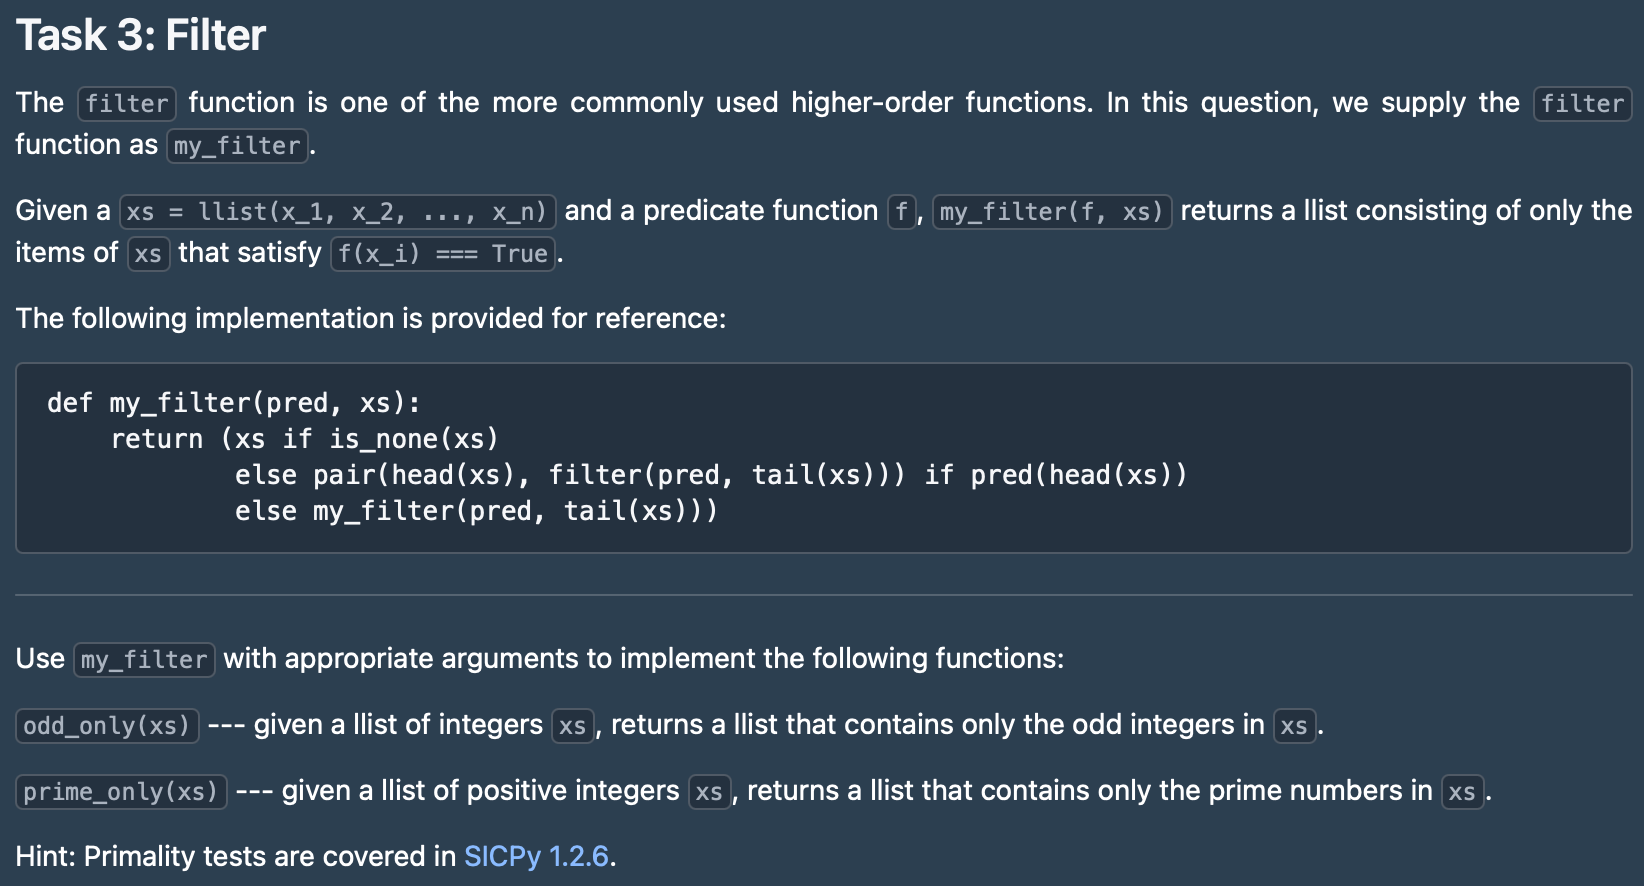

In [21]:
def my_filter(pred, xs):
    return (xs if is_none(xs)
            else pair(head(xs), filter(pred, tail(xs))) if pred(head(xs))
            else my_filter(pred, tail(xs)))

# Given llist of integers xs, returns llist that contains only the odd integers in xs
def odd_only(xs):
    return my_filter(lambda x: x%2==1, xs)

# Given llist of positive integers xs, returns llist that contains only prime numbers
def prime_only(xs):
    def helper(i, counter):
        if i==1: return False
        elif counter==i: return True
        elif i%counter== 0: return False
        else: return helper(i, counter+1)
    return my_filter(lambda x: helper(x, 2), xs)

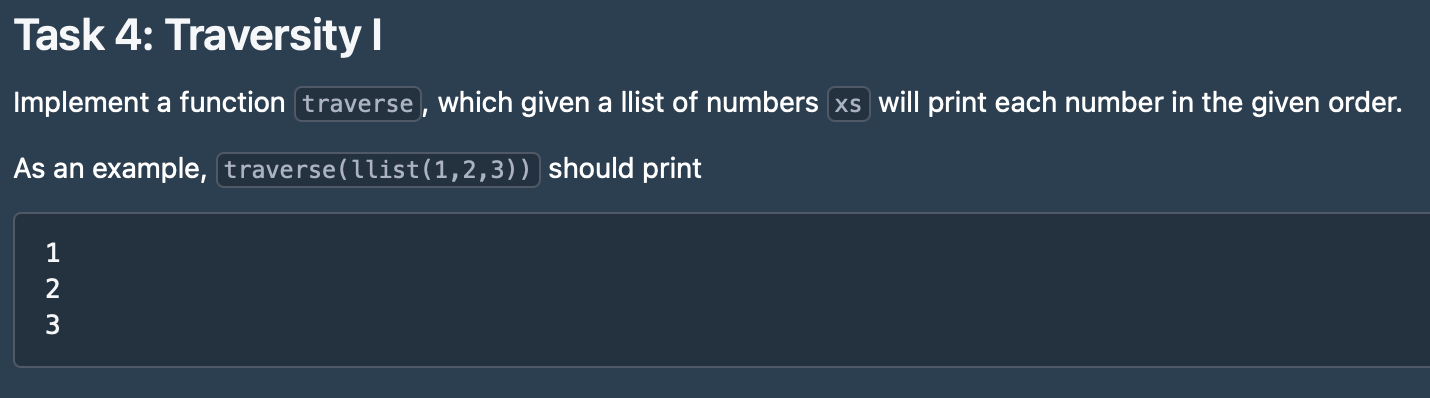

In [22]:
def traverse(xs):
    if xs==None: return xs
    else: print(head(xs))
    if tail(xs)==None: return None
    else: return traverse(tail(xs))

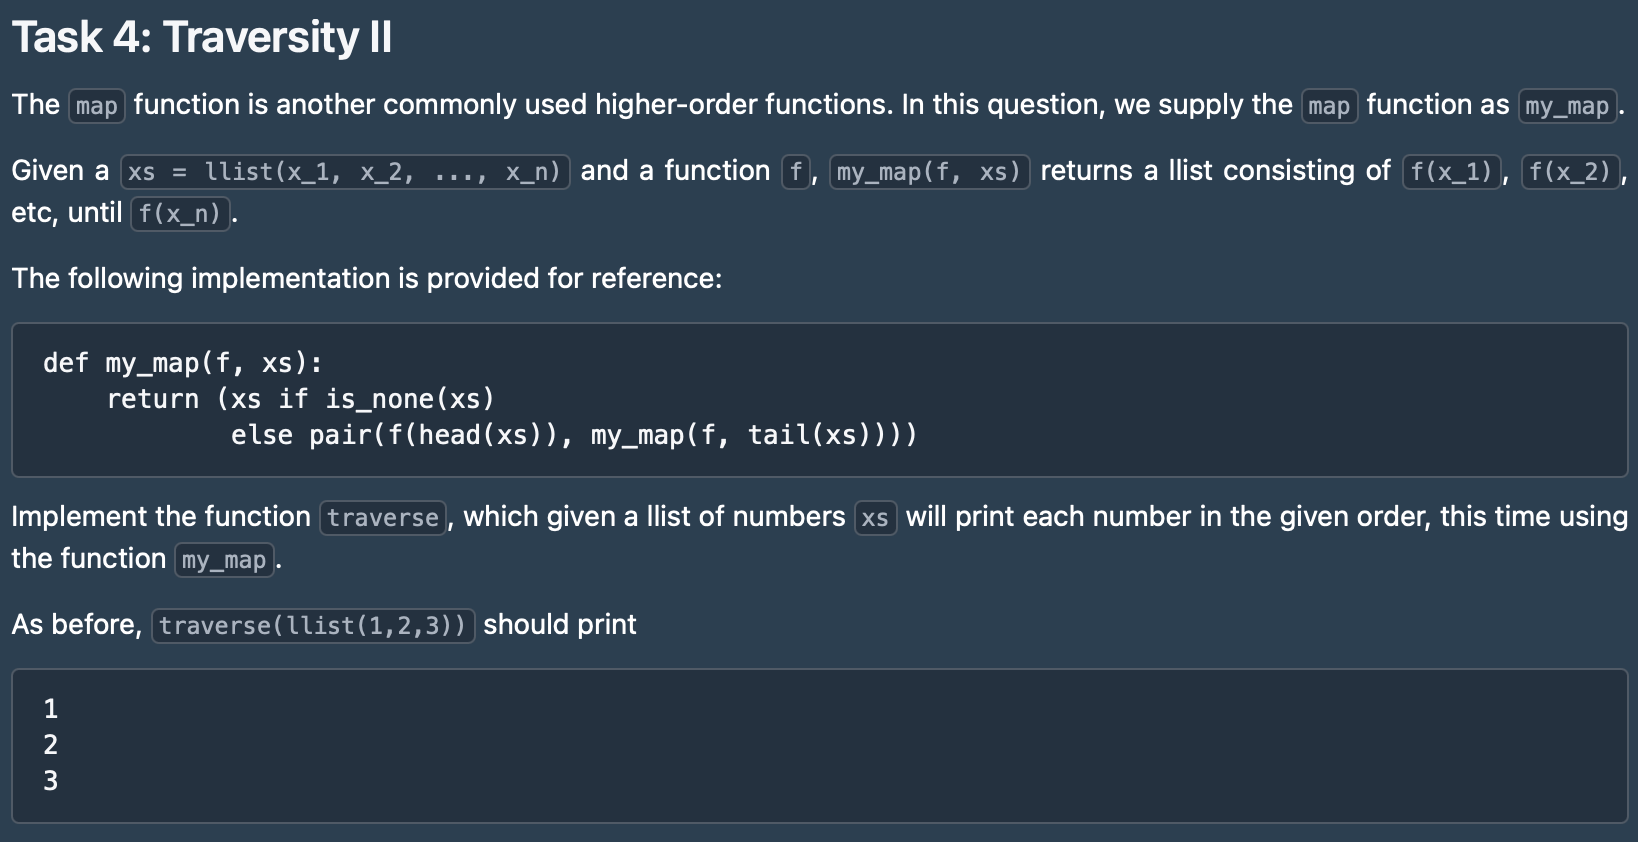

In [23]:
def my_map(f, xs):
    return (xs if is_none(xs)
            else pair(f(head(xs)), my_map(f, tail(xs))))

def traverse(xs): 
    return my_map(lambda x: print(x), xs)

# REC 5 [10/09/26]

space complexity used to be about maximum accumulated number of deferred operations at a certain step (so basically if a deferred operation gets evaluated its not counted) <br>
smth smth analogy about 1TB storage space in laptop and once it gets full u move the data and use more data so youd dealt with more than 1TB data but the "space complexity" is kinda just still 1TB <br>
now we gotta look at pairs too ; but once the pairs aren't needed anymore they are "discarded" and not counted within space complexity anymore basically same thing<br>

In [ ]:
# NOTE: append(None, llist(3, 4, 5)) -> returns llist(3, 4, 5) not llist(None, 3, 4, 5)
# why? bec 

def append(xs, ys):
    return (ys 
            if is_none(xs)
            else pair(head(xs), append(tail(xs), ys)))

# is_none(xs) -> True -> returns ys immediately
# llist(None) = [None, None] ≠ None

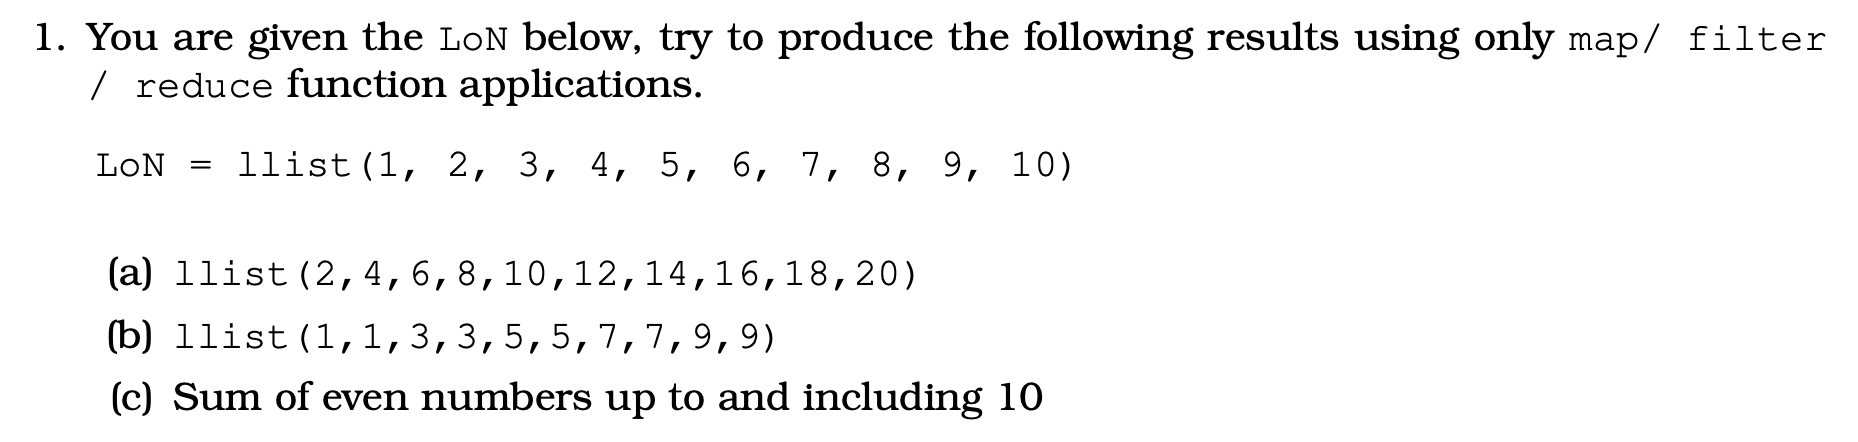

In [ ]:
# (a) creates a llist w each element having twice the original value
def doubles(xs): 
    return map(lambda x: 2*x, xs)

# (b) if odd then returns. if even then -1.
def weirdfun(xs): 
    return map(lambda x: x if x%2==1 else x-1, xs) #u can use if/else in the map()!

# (c) sum of even numbers up to and including 10
def summ(xs):
    return reduce(lambda x, y: x+y, 0, filter(lambda x: x%2==0, xs))

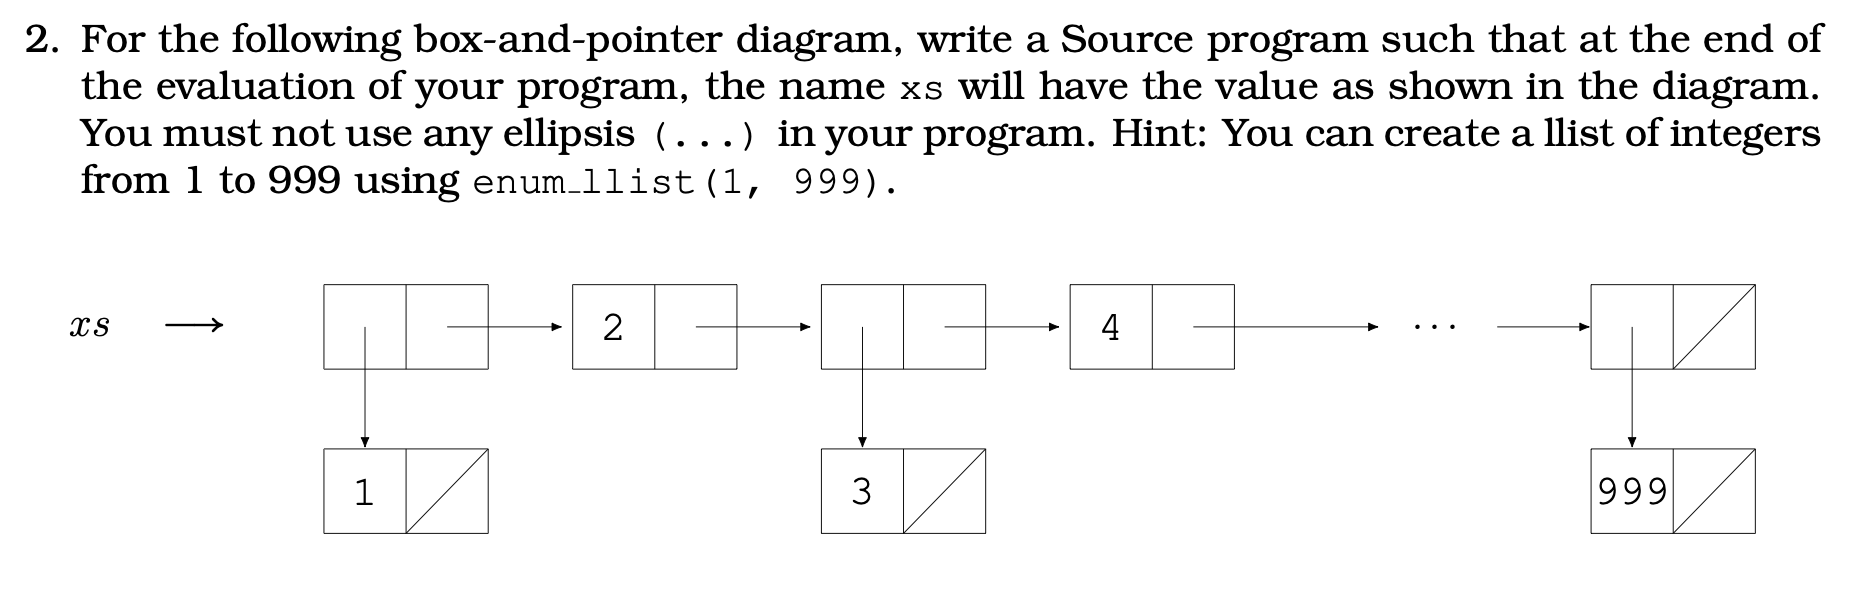

In [ ]:
xs = enum_llist(1, 999) #creates llist with (1, 2, ..., 999)
def change(xs): 
    return map(lambda x: x if x%2==0 else llist(x), xs)
change(xs)

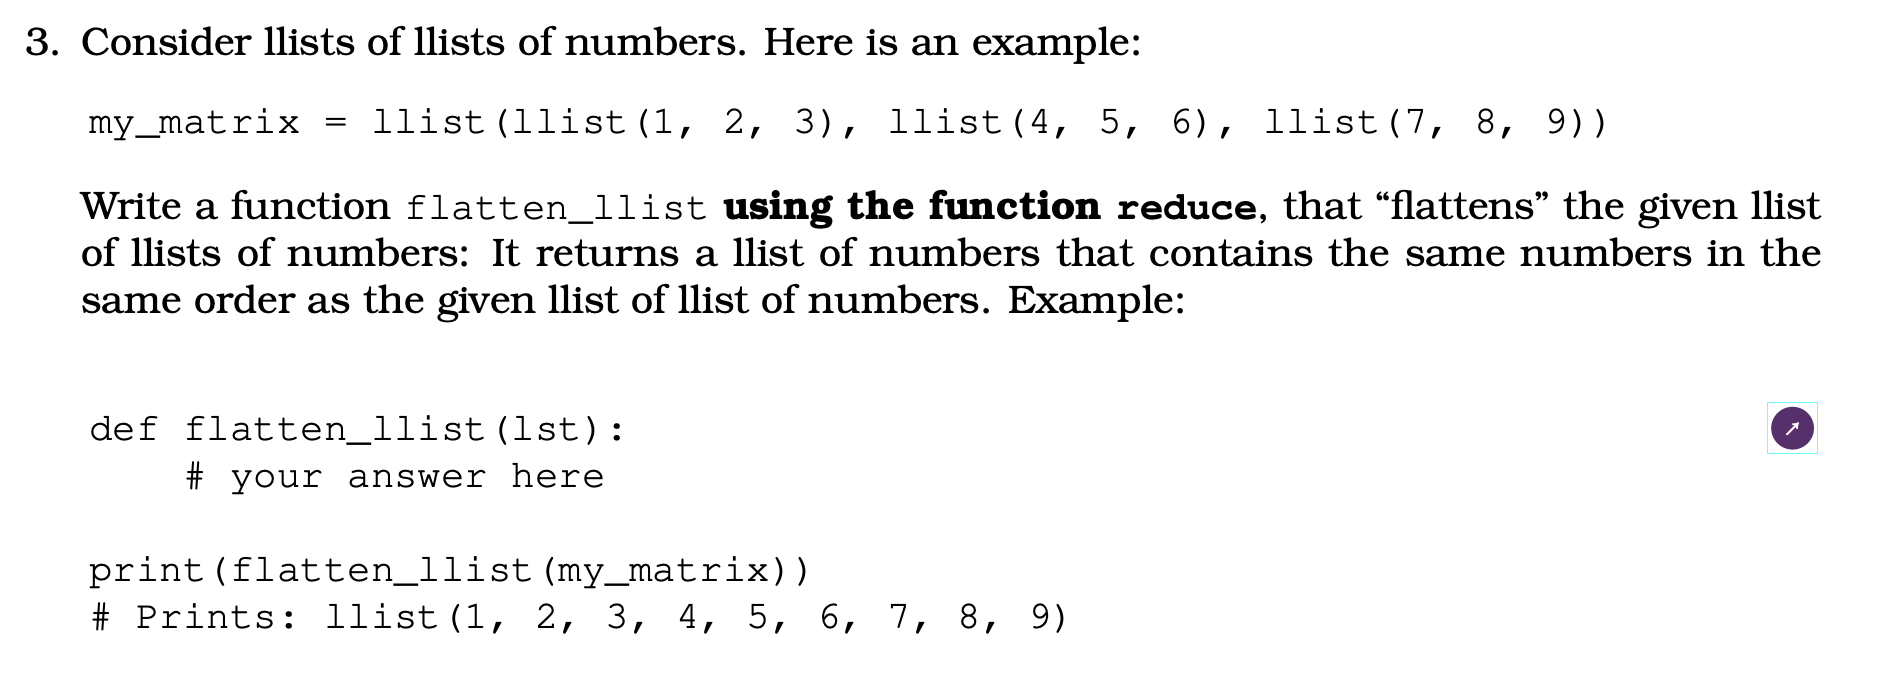

In [ ]:
my_matrix = llist(llist(1, 2, 3), llist(4, 5, 6), llist(7, 8, 9))
# need to get llist(1, 2, 3, 4, 5, 6, 7, 8, 9)

def reduce(op, initial, xs):
    return (initial
            if is_none(xs)
            else op(head(xs), reduce(op, initial, tail(xs))))

def flatten_llist(xs): #bro idk ill try later
    return ...